In [1]:
%matplotlib inline
import os, sys, gc, warnings
import numpy as np
import pandas as pd
# import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CAFPYANA_WD = '/home/castalyf/cafpyana'
for p in [CAFPYANA_WD, CAFPYANA_WD + '/pyanalib']:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis_village.unfolding.covariance import (
    get_covariance_matrix_self, get_covariance_matrix)
from analysis_village.unfolding.utils import plot_univ_hists, plot_heatmap

# ── Paths ─────────────────────────────────────────────────────────────────────
DF_FILE      = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_2605.df'
WEIGHTS_FILE = '/home/castalyf/cafpyana_out/nueCC_weights_test.df'
DF_OUT_DIR   = './nuecc_dfs'
SYST_DIR     = './saved_syst'
PLOT_DIR     = './plots_syst'
TARGET_POT   = 6.6e20
TITLE        = r'SBND $\nu_e$ CC Inclusive'
POT_LABEL    = r'$6.6\times10^{20}$ POT'

for d in [SYST_DIR, PLOT_DIR,
          f'{PLOT_DIR}/univ', f'{PLOT_DIR}/cov', f'{PLOT_DIR}/fracunc']:
    os.makedirs(d, exist_ok=True)
print('Paths OK')


Paths OK


In [4]:
def _load_hdf_key(hdf_file, key_prefix):
    with pd.HDFStore(hdf_file, mode='r') as store:
        keys = store.keys()
        if '/split' in keys:
            n = int(store['split']['n_split'].iloc[0])
            return pd.concat([store[f'{key_prefix}_{k}'] for k in range(n)])
        matching = sorted(k for k in keys if k.lstrip('/').startswith(key_prefix.lstrip('/')))
        if not matching:
            return pd.DataFrame()
        return pd.concat([store[k] for k in matching])

histpotdf = _load_hdf_key(DF_FILE, 'histpotdf')
statsdf   = _load_hdf_key(DF_FILE, 'stats')

pot_col   = 'TotalPOT' if 'TotalPOT' in histpotdf.columns \
            else histpotdf.select_dtypes('number').columns[0]
total_pot = float(histpotdf[pot_col].sum())
pot_scale = TARGET_POT / total_pot
n_true_signal = int(statsdf['n_true_signal'].sum())

print(f'Total POT    : {total_pot:.3e}')
print(f'Target POT   : {TARGET_POT:.3e}')
print(f'pot_scale    : {pot_scale:.4f}')
print(f'True signal  : {n_true_signal:,}')
del histpotdf, statsdf; gc.collect()

SEL_TOPO_FILE = f'{DF_OUT_DIR}/selected_nuecc_topo_v2.df'
sel_topo = pd.read_hdf(SEL_TOPO_FILE)
print(f'\nsel_topo shape : {sel_topo.shape}')
print(f'sel_topo cols  : {list(sel_topo.columns)}')


Total POT    : 7.523e+19
Target POT   : 6.600e+20
pot_scale    : 8.7735
True signal  : 2,202

sel_topo shape : (487797, 13)
sel_topo cols  : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'pot_scale']


In [9]:
## Cell 2 — Load Weights & Detect Universe Columns


mcnu_df = _load_hdf_key(WEIGHTS_FILE, 'mcnu')
print(f'mcnu_df shape : {mcnu_df.shape}')
print(f'mcnu_df index : {mcnu_df.index.names}')

def _is_univ(c):
    return isinstance(c, tuple) and any('univ' in str(p).lower() for p in c)
def _matches(c, kws):
    return isinstance(c, tuple) and any(
        any(kw in str(p).lower() for kw in kws) for p in c)

all_cols   = list(mcnu_df.columns)
bnb_cols   = [c for c in all_cols if _is_univ(c) and _matches(c,
              ['flux','bnb','beam','expskin','horncurrent','kplus','kminus',
               'kzero','piplus','piminus','nucleon','pion'])]
genie_cols = [c for c in all_cols if _is_univ(c) and _matches(c, ['genie','xsr','knob'])]
if not bnb_cols:
    bnb_cols   = [c for c in all_cols if _is_univ(c) and _matches(c, ['flux'])]
if not genie_cols:
    genie_cols = [c for c in all_cols if _is_univ(c) and _matches(c, ['genie'])]

print(f'BNB cols  : {len(bnb_cols)}')
print(f'GENIE cols: {len(genie_cols)}')

# Extract weight columns immediately, then free the full mcnu_df
print(f'mcnu_sub shape: {mcnu_sub.shape}')

mcnu_df shape : (17536, 304)
mcnu_df index : ['__ntuple', 'entry', 'rec.mc.nu..index']
BNB cols  : 100
GENIE cols: 100
mcnu_sub shape: (17536, 200)


In [10]:

print('Reading mct_index column from evtdf ...')
with pd.HDFStore(DF_FILE, mode='r') as store:
    keys = store.keys()
    if '/split' in keys:
        n = int(store['split']['n_split'].iloc[0])
        evt_keys = [f'/evt_{k}' for k in range(n)]
    else:
        evt_keys = sorted(k for k in keys if k.lstrip('/').startswith('evt'))

with pd.HDFStore(DF_FILE, mode='r') as store:
    sample_cols = store[evt_keys[0]].columns.tolist()

mct_col = next((c for c in sample_cols
                if 'mct_index' in str(c) and 'dlp_true' in str(c)), None)
if mct_col is None:
    mct_col = next((c for c in sample_cols if 'mct_index' in str(c)), None)
print(f'mct_index column: {mct_col}')

mct_frames = []
for ek in tqdm(evt_keys, desc='chunks'):
    with pd.HDFStore(DF_FILE, mode='r') as store:
        chunk = store[ek][[mct_col]]
    il = chunk.index.names[:-1] if chunk.index.nlevels > 1 else chunk.index.names
    mct_frames.append(chunk.groupby(level=il).first()); del chunk
mct_inter = pd.concat(mct_frames); del mct_frames; gc.collect()
print(f'mct_inter shape: {mct_inter.shape}')

# Merge with mcnu weights
wgt_cols  = bnb_cols + genie_cols
mcnu_sub  = mcnu_df[wgt_cols].copy() if wgt_cols else pd.DataFrame(index=mcnu_df.index)
del mcnu_df; gc.collect()

mcnu_idx   = mcnu_sub.index.names
inter_idx  = list(mct_inter.index.names)
mct_r  = mct_inter.reset_index()
mcnu_r = mcnu_sub.reset_index()

# ── Flatten MultiIndex columns to plain strings before merging ─────────────────
def _flat(cols):
    return ['|'.join(str(p) for p in c).strip('|') if isinstance(c, tuple) else str(c)
            for c in cols]

mct_r.columns  = _flat(mct_r.columns)
mcnu_r.columns = _flat(mcnu_r.columns)

# Re-derive key names after flattening
inter_idx_flat = _flat(inter_idx)      # ['__ntuple', 'entry', 'rec.dlp..index']
mcnu_idx_flat  = _flat(mcnu_idx)       # ['__ntuple', 'entry', 'rec.mc.nu..index']
mct_col_flat   = _flat([mct_col])[0]   # 'rec|dlp_true|mct_index||'
wgt_cols_flat  = _flat(wgt_cols)

merged = mct_r.merge(
    mcnu_r,
    left_on  = [inter_idx_flat[0], inter_idx_flat[1], mct_col_flat],
    right_on = [mcnu_idx_flat[0],  mcnu_idx_flat[1],  mcnu_idx_flat[2]],
    how='left',
)
merged = merged.set_index(inter_idx_flat)

# Restore original tuple column names so downstream cells are unaffected
wgt_aligned = merged[wgt_cols_flat].copy()
wgt_aligned.columns    = wgt_cols   # put tuple cols back
wgt_aligned.index.names = inter_idx  # restore original index names

del mct_r, mcnu_r, merged, mct_inter, mcnu_sub; gc.collect()

bnb_cols_aligned   = [c for c in wgt_aligned.columns if c in set(bnb_cols)]
genie_cols_aligned = [c for c in wgt_aligned.columns if c in set(genie_cols)]
print(f'wgt_aligned: {wgt_aligned.shape}  BNB={len(bnb_cols_aligned)}  GENIE={len(genie_cols_aligned)}')


Reading mct_index column from evtdf ...
mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


chunks:   0%|          | 0/1 [00:00<?, ?it/s]

mct_inter shape: (487797, 1)
wgt_aligned: (487797, 200)  BNB=100  GENIE=100


In [11]:

RECO_BINS   = np.linspace(0, 2000, 11)
TRUE_BINS   = np.linspace(0, 2000, 11)
COS_BINS    = np.linspace(-1, 1, 11)
FINAL_STAGE = 'sel_single_electron'   # or 'sel_conversion_gap' for qual cuts

class VarConfig:
    def __init__(self, name, bins, xlabel):
        self.name          = name
        self.bins          = bins
        self.bin_centers   = 0.5 * (bins[:-1] + bins[1:])
        self.var_plot_name = xlabel
        self.var_labels    = [xlabel, xlabel, xlabel.replace('Reco','True')]
        self.pot_label     = POT_LABEL

VAR_CFGS = [
    VarConfig('reco_ke',       RECO_BINS, r'Reco leading-$e^-$ KE [MeV]'),
    VarConfig('reco_costheta', COS_BINS,  r'Reco leading-$e^-$ $\cos\theta$'),
]
print('VarConfigs ready:')
for v in VAR_CFGS:
    print(f'  {v.name}  n_bins={len(v.bins)-1}')


VarConfigs ready:
  reco_ke  n_bins=10
  reco_costheta  n_bins=10


In [12]:

_eps = 1e-8

def build_cv(sel_df, stage_col, var_col, bins, ps,
             true_col=None, true_bins=None):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - _eps).values
    w    = np.full(len(sel), ps)
    sig_cv, _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
    bkg_cv, _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    out = dict(sig_cv=sig_cv, bkg_cv=bkg_cv)
    if true_col and true_bins is not None:
        tv = sel.loc[smk, true_col].dropna()
        true_cv, _ = np.histogram(
            tv.clip(true_bins[0], true_bins[-1] - _eps),
            bins=true_bins, weights=np.full(len(tv), ps))
        valid = smk & sel[var_col].notna().values & sel[true_col].notna().values
        r2d, _, _ = np.histogram2d(
            sel.loc[valid, true_col].clip(true_bins[0], true_bins[-1] - _eps),
            sel.loc[valid, var_col].clip(bins[0], bins[-1] - _eps),
            bins=[true_bins, bins])
        out['true_sig_cv'] = true_cv
        out['response']    = r2d / r2d.sum(axis=1, keepdims=True).clip(1)
    return out

cv_results = {}
for vcfg in VAR_CFGS:
    tc = 'true_ke' if vcfg.name == 'reco_ke' else 'true_costheta'
    tb = TRUE_BINS if vcfg.name == 'reco_ke'  else vcfg.bins
    cv_results[vcfg.name] = build_cv(
        sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale, tc, tb)
    cv = cv_results[vcfg.name]
    print(f'{vcfg.name}: sig={cv["sig_cv"].sum():.1f}  bkg={cv["bkg_cv"].sum():.1f}')
print('CV done.')


reco_ke: sig=15783.5  bkg=87805.0
reco_costheta: sig=15783.5  bkg=87805.0
CV done.


In [13]:

def build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
                     var_col, bins, ps, clip=10.0):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
    nwl  = wgt_aligned.index.nlevels
    sidx = (sel.index.droplevel(list(range(nwl, sel.index.nlevels)))
            if sel.index.nlevels > nwl else sel.index)
    wmat = wgt_aligned[univ_cols].reindex(sidx).values.astype(np.float32)
    nu   = len(univ_cols); nb = len(bins) - 1
    su   = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
    for ui in tqdm(range(nu), desc=var_col, leave=False):
        w = np.where(np.isfinite(wmat[:, ui]), wmat[:, ui].astype(float), 1.0)
        w = np.clip(w, 0.0, clip) * ps
        su[ui], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[ui], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    return su, bu

SRC_LABEL    = {'flux': 'BNB Flux', 'genie': 'GENIE', 'mcstat': 'MCstat'}
univ_results = {}

for vcfg in VAR_CFGS:
    univ_results[vcfg.name] = {}
    if bnb_cols_aligned:
        print(f'[{vcfg.name}] BNB ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  bnb_cols_aligned, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name]['flux'] = {'sig': su, 'bkg': bu}
    if genie_cols_aligned:
        print(f'[{vcfg.name}] GENIE ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  genie_cols_aligned, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name]['genie'] = {'sig': su, 'bkg': bu}
    gc.collect()
print('Flux/GENIE universes done.')


[reco_ke] BNB ...


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] GENIE ...


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] BNB ...


reco_costheta:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] GENIE ...


reco_costheta:   0%|          | 0/100 [00:00<?, ?it/s]

Flux/GENIE universes done.


In [14]:

from numpy.random import Generator, PCG64, SeedSequence

def build_mcstat_univs(sel_df, stage_col, var_col, bins, ps, nu=100, seed=42):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
    ne   = len(sel); ss = SeedSequence(seed); kids = ss.spawn(nu)
    nb   = len(bins) - 1; su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
    for u in tqdm(range(nu), desc=f'{var_col} MCstat', leave=False):
        w = Generator(PCG64(kids[u])).poisson(1.0, size=ne) * ps
        su[u], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[u], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    return su, bu

for vcfg in VAR_CFGS:
    print(f'[{vcfg.name}] MCstat ...')
    su, bu = build_mcstat_univs(sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale)
    univ_results[vcfg.name]['mcstat'] = {'sig': su, 'bkg': bu}

del wgt_aligned, bnb_cols_aligned, genie_cols_aligned; gc.collect()
print('MCstat done. Weights freed.')


[reco_ke] MCstat ...


reco_ke MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] MCstat ...


reco_costheta MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

MCstat done. Weights freed.


In [15]:

def _mat(block):
    return block.get('cov', block) if isinstance(block, dict) else block

def compute_covs(su, bu, s_cv, b_cv):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return {
            'cov_ms_ms': get_covariance_matrix_self(su, s_cv),
            'cov_bs_bs': get_covariance_matrix_self(bu, b_cv),
            'cov_ms_bs': get_covariance_matrix(su, s_cv, bu, b_cv),
            'cov_bs_ms': get_covariance_matrix(bu, b_cv, su, s_cv),
        }

cov_results = {}
for vcfg in VAR_CFGS:
    cov_results[vcfg.name] = {}
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        print(f'[{vcfg.name}] cov: {src} ...')
        cov_results[vcfg.name][src] = compute_covs(
            ud['sig'], ud['bkg'], cv['sig_cv'], cv['bkg_cv'])
print('All covariances computed.')


[reco_ke] cov: flux ...
[reco_ke] cov: genie ...
[reco_ke] cov: mcstat ...
[reco_costheta] cov: flux ...
[reco_costheta] cov: genie ...
[reco_costheta] cov: mcstat ...
All covariances computed.


In [16]:

def save_npz(path, cv, covs, extra=None):
    p = dict(ms=cv['sig_cv'], bs=cv['bkg_cv'])
    if 'true_sig_cv' in cv: p['true_signal'] = cv['true_sig_cv']
    if 'response'    in cv: p['response']    = cv['response']
    for bk, bv in covs.items():
        if isinstance(bv, dict):
            for k, v in bv.items():
                if isinstance(v, np.ndarray): p[f'{bk}_{k}'] = v
        else:
            p[bk] = bv
    if extra: p.update(extra)
    np.savez(path, **p)
    print(f'  {os.path.basename(path)}  ({os.path.getsize(path)/1024:.0f} KB)')

for vcfg in VAR_CFGS:
    vd = os.path.join(SYST_DIR, vcfg.name); os.makedirs(vd, exist_ok=True)
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        save_npz(os.path.join(vd, f'{src}_cov_matrices.npz'), cv, covs)
    if len(cov_results[vcfg.name]) > 1:
        ts = sum(_mat(cov_results[vcfg.name][s]['cov_ms_ms'])
                 for s in cov_results[vcfg.name])
        tb = sum(_mat(cov_results[vcfg.name][s]['cov_bs_bs'])
                 for s in cov_results[vcfg.name])
        save_npz(os.path.join(vd, 'total_cov_matrices.npz'), cv, {},
                 extra=dict(total_cov_ms_ms=ts, total_cov_bs_bs=tb))
print(f'\nAll NPZ saved to {SYST_DIR}/')


  flux_cov_matrices.npz  (14 KB)
  genie_cov_matrices.npz  (14 KB)
  mcstat_cov_matrices.npz  (14 KB)
  total_cov_matrices.npz  (4 KB)
  flux_cov_matrices.npz  (14 KB)
  genie_cov_matrices.npz  (14 KB)
  mcstat_cov_matrices.npz  (14 KB)
  total_cov_matrices.npz  (4 KB)

All NPZ saved to ./saved_syst/


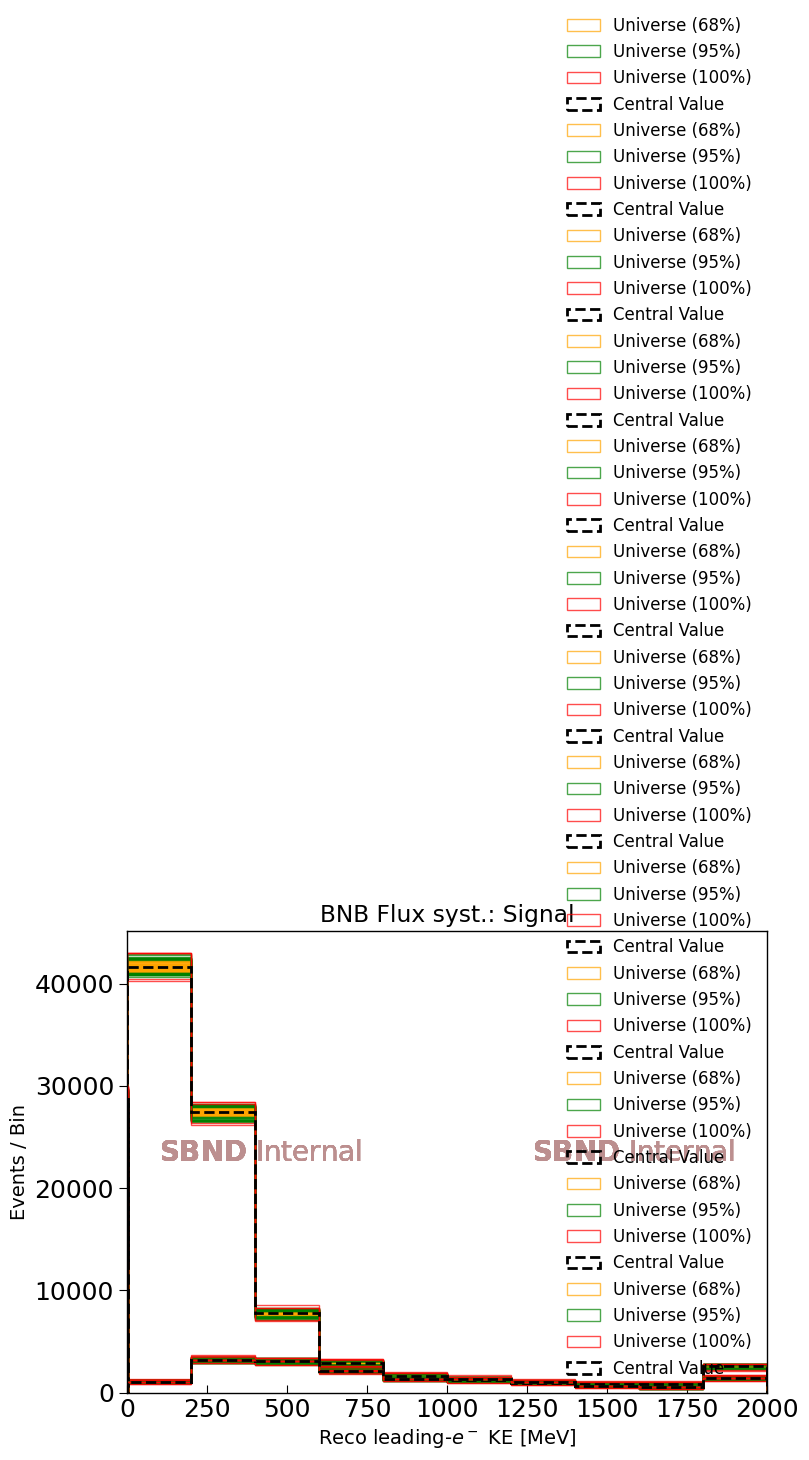

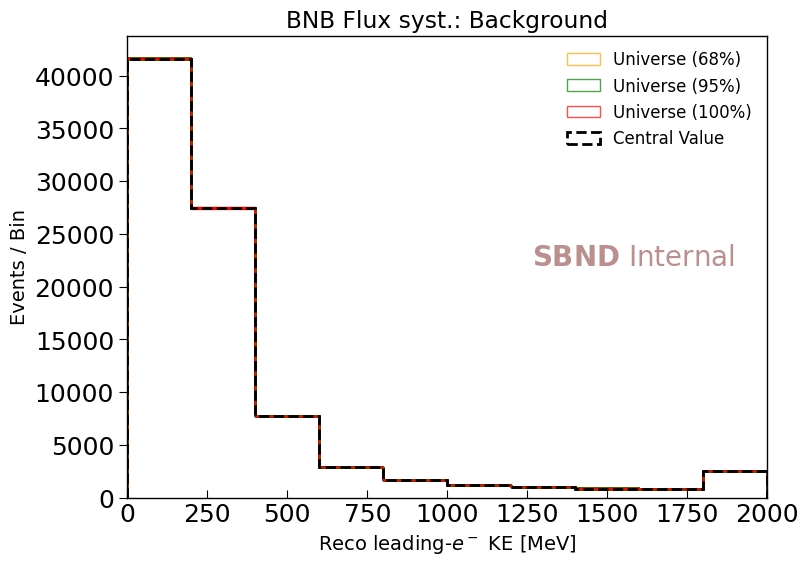

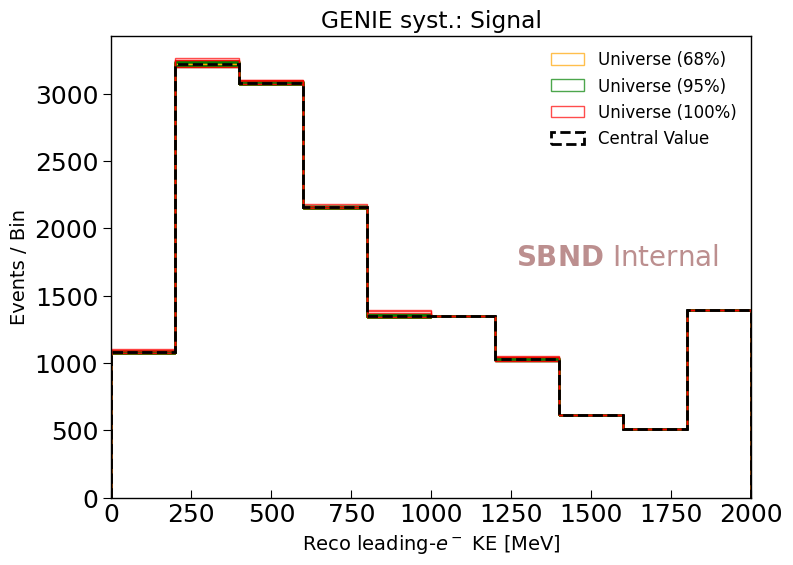

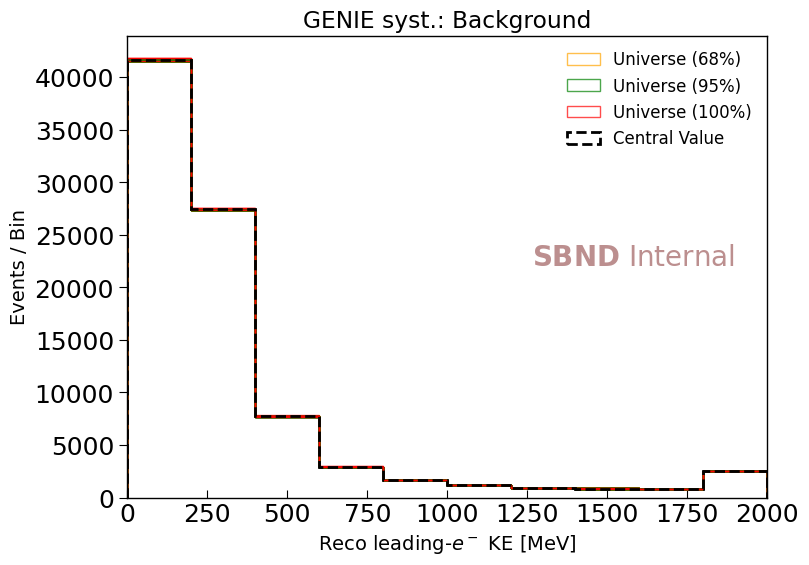

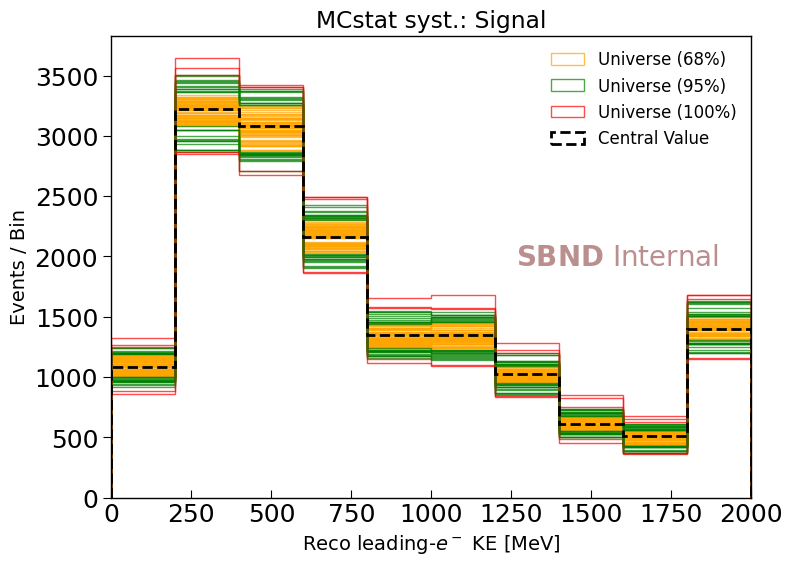

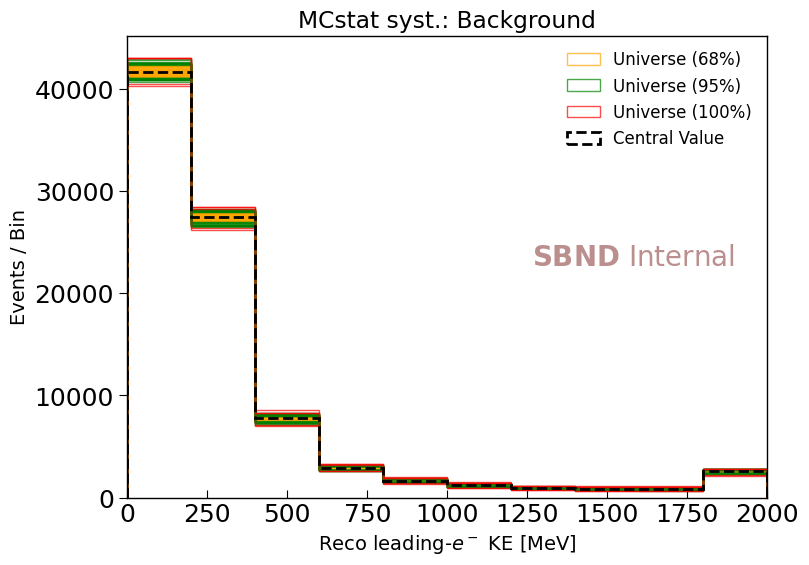

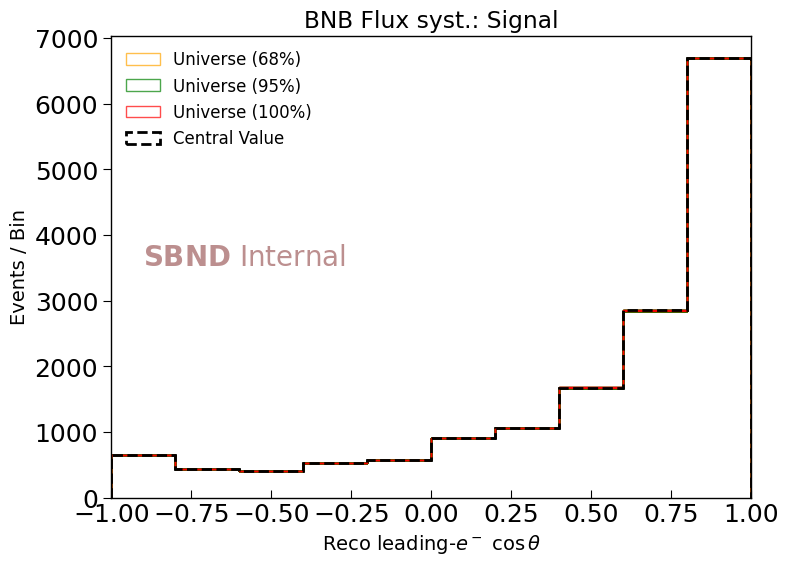

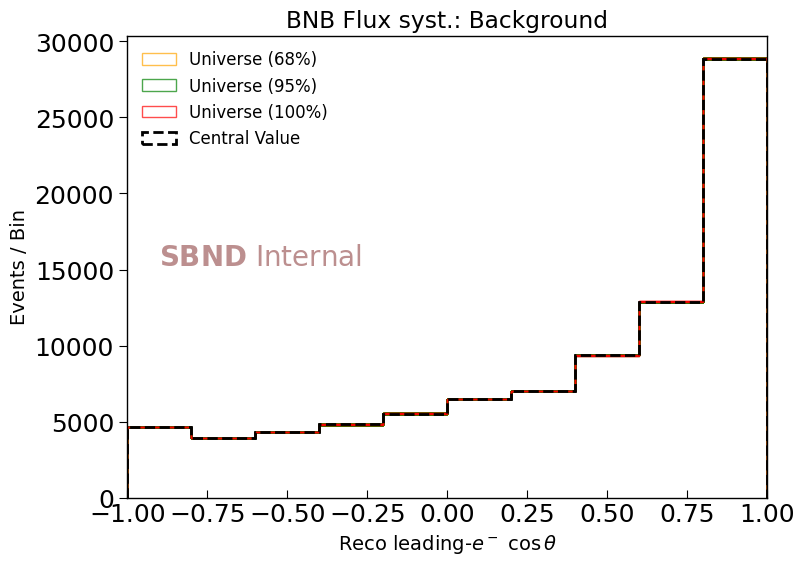

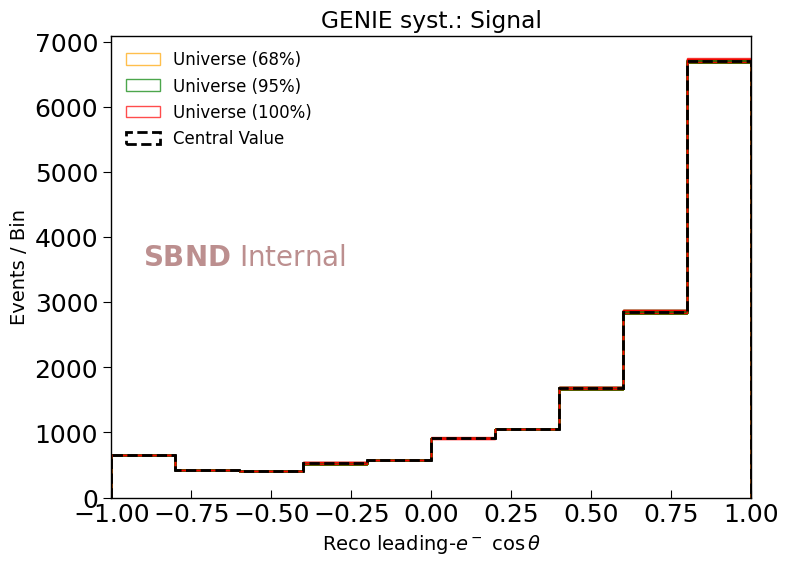

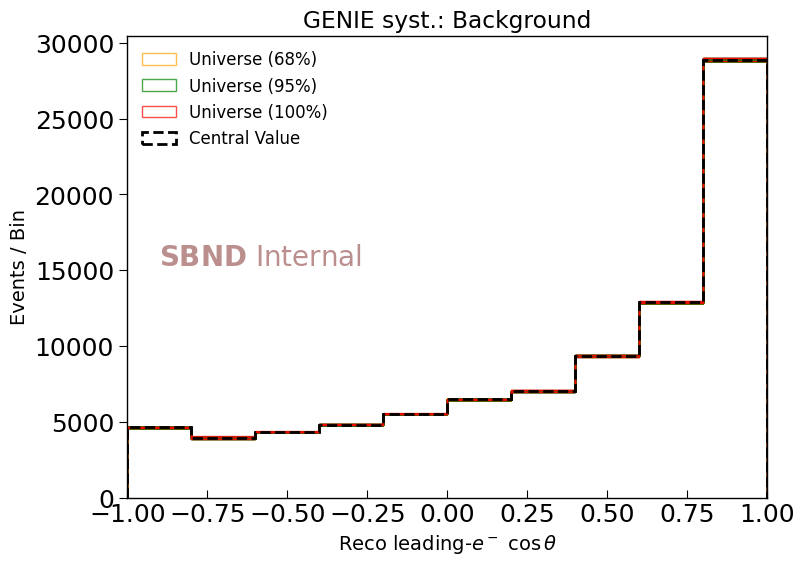

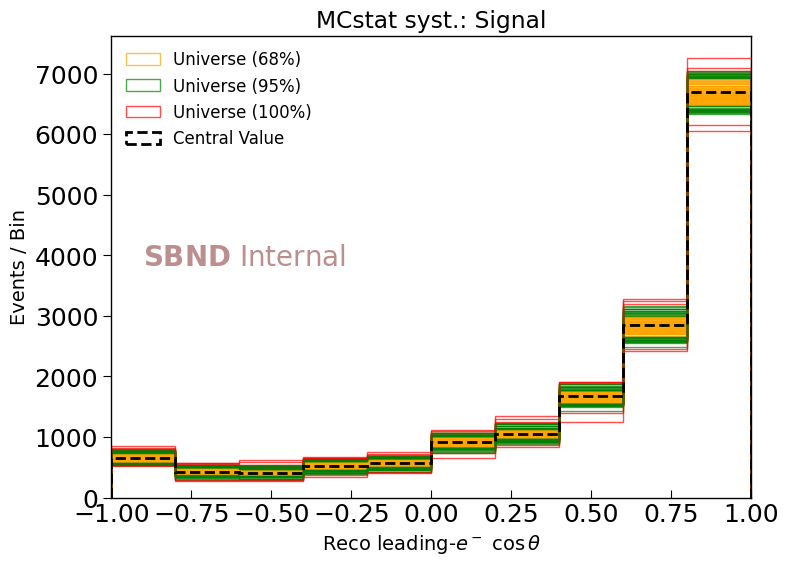

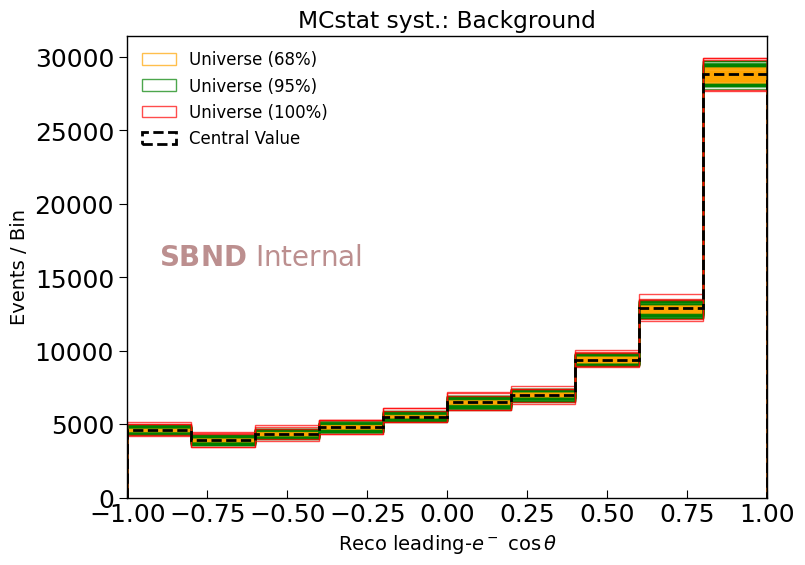

Universe plots -> plots_syst/univ/


In [24]:
def savefig(fig, name, sub=''):
    d = os.path.join(PLOT_DIR, sub) if sub else PLOT_DIR
    os.makedirs(d, exist_ok=True)
    fig.savefig(os.path.join(d, f'{name}.png'), dpi=150, bbox_inches='tight')
    display(fig)       # show inline in notebook
    plt.close(fig)

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        for categ, cv_arr, ua in [
            ('Signal',     cv['sig_cv'], ud['sig']),
            ('Background', cv['bkg_cv'], ud['bkg']),
        ]:
            try:
                plot_univ_hists(ua, cv_arr, SRC_LABEL[src], vcfg, categ_name=categ)
                fig = plt.gcf()   # grab whatever was just created
                savefig(fig, f'{vcfg.name}_{src}_{categ.lower()}_univs', 'univ')
            except Exception as e:
                print(f'  [WARN] {vcfg.name}/{src}/{categ}: {e}')
                plt.close('all')

print('Universe plots -> plots_syst/univ/')

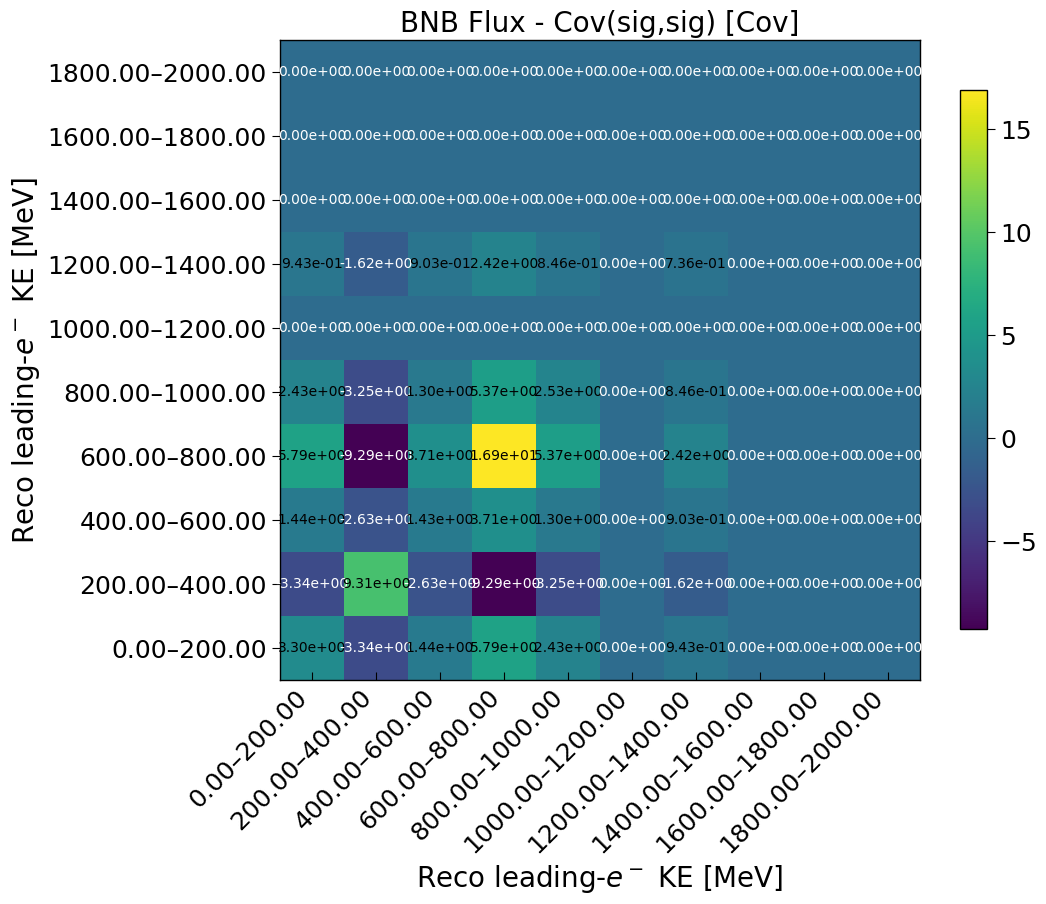

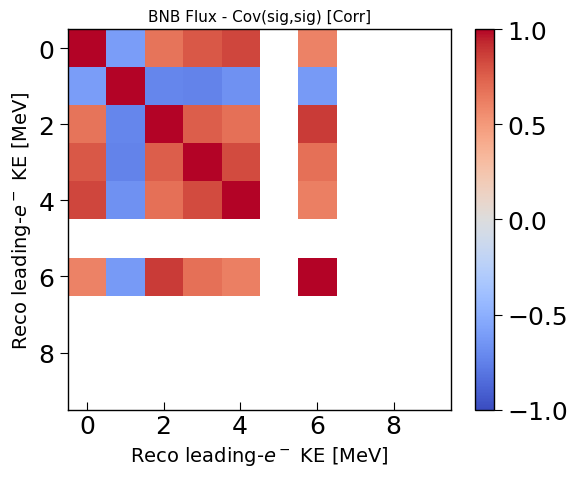

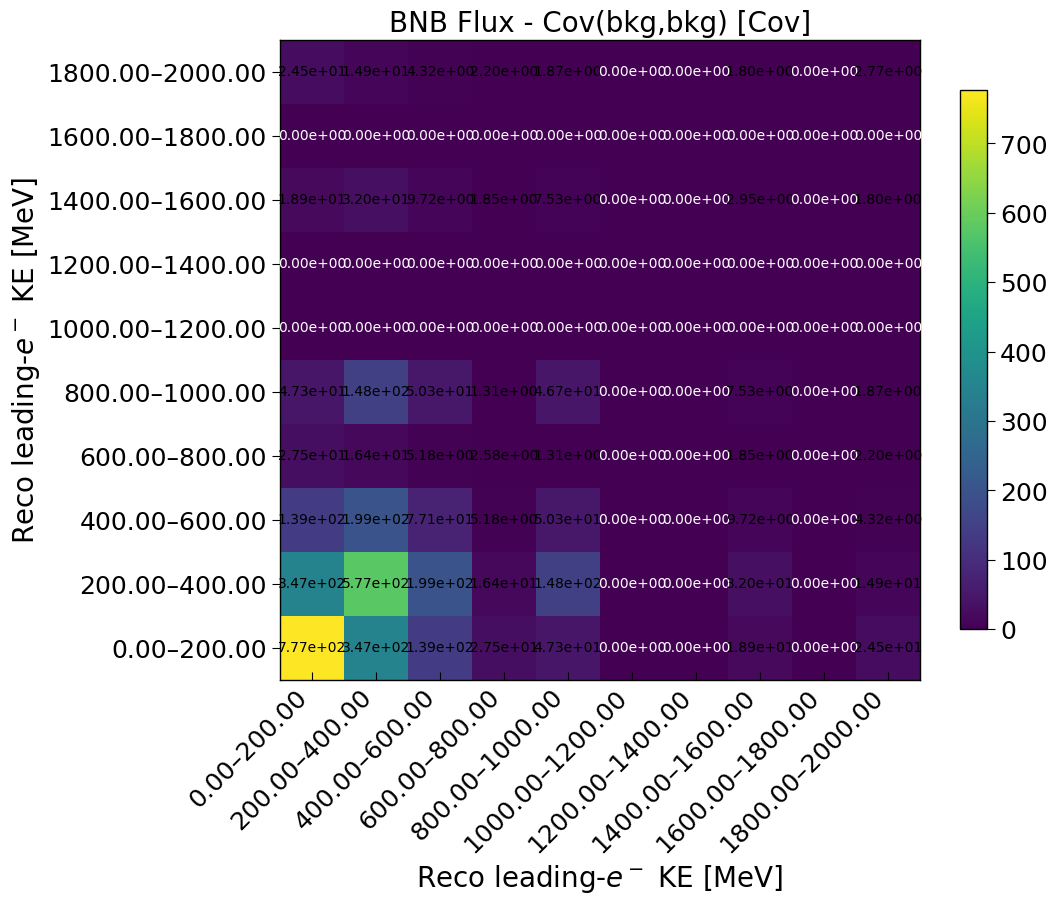

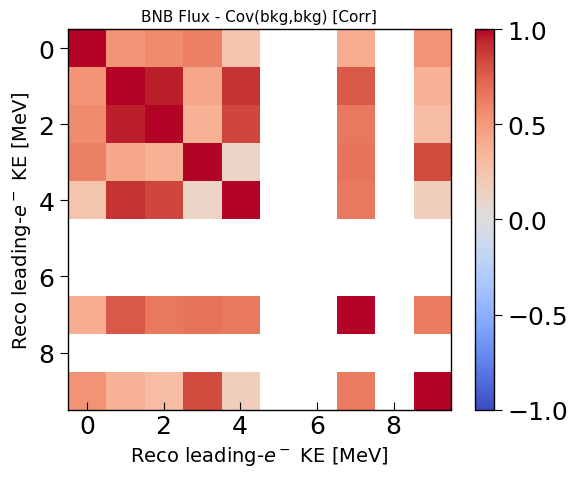

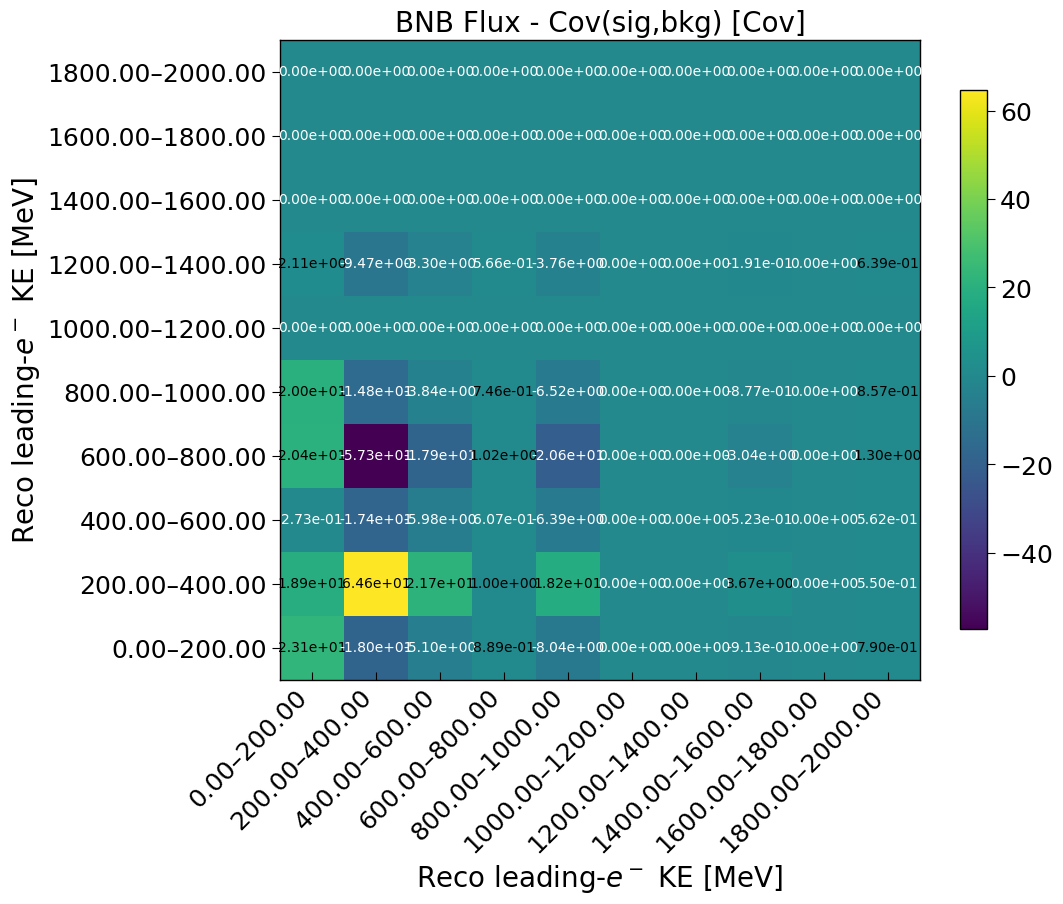

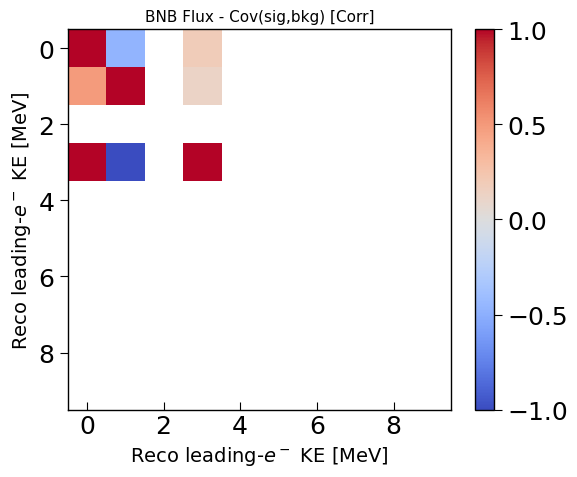

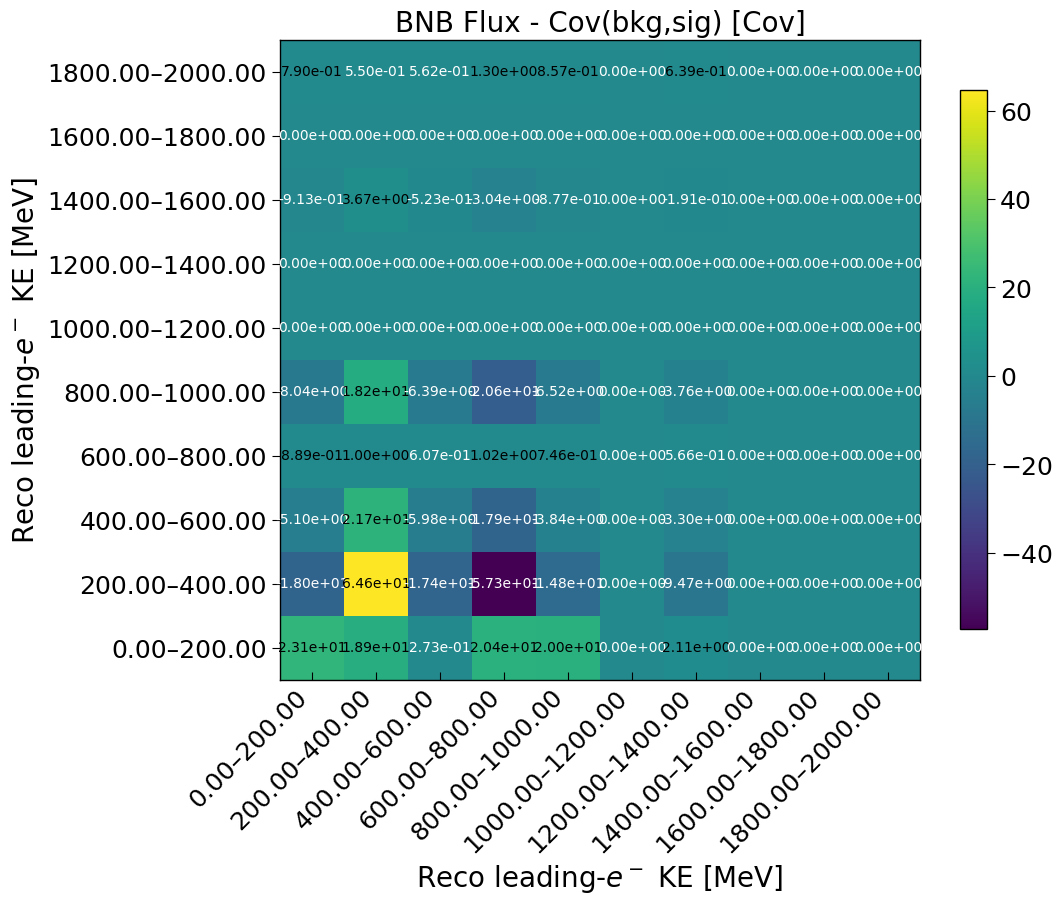

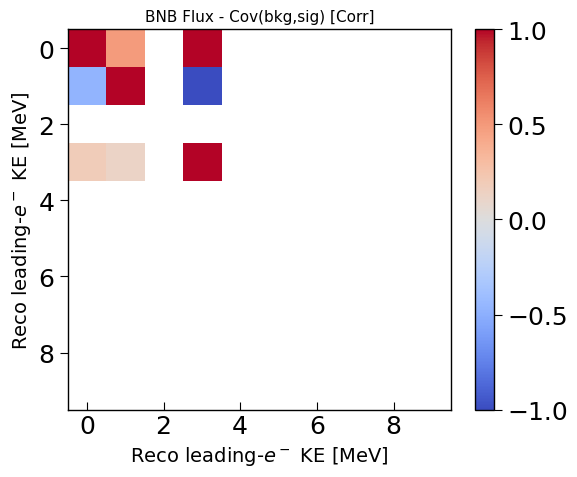

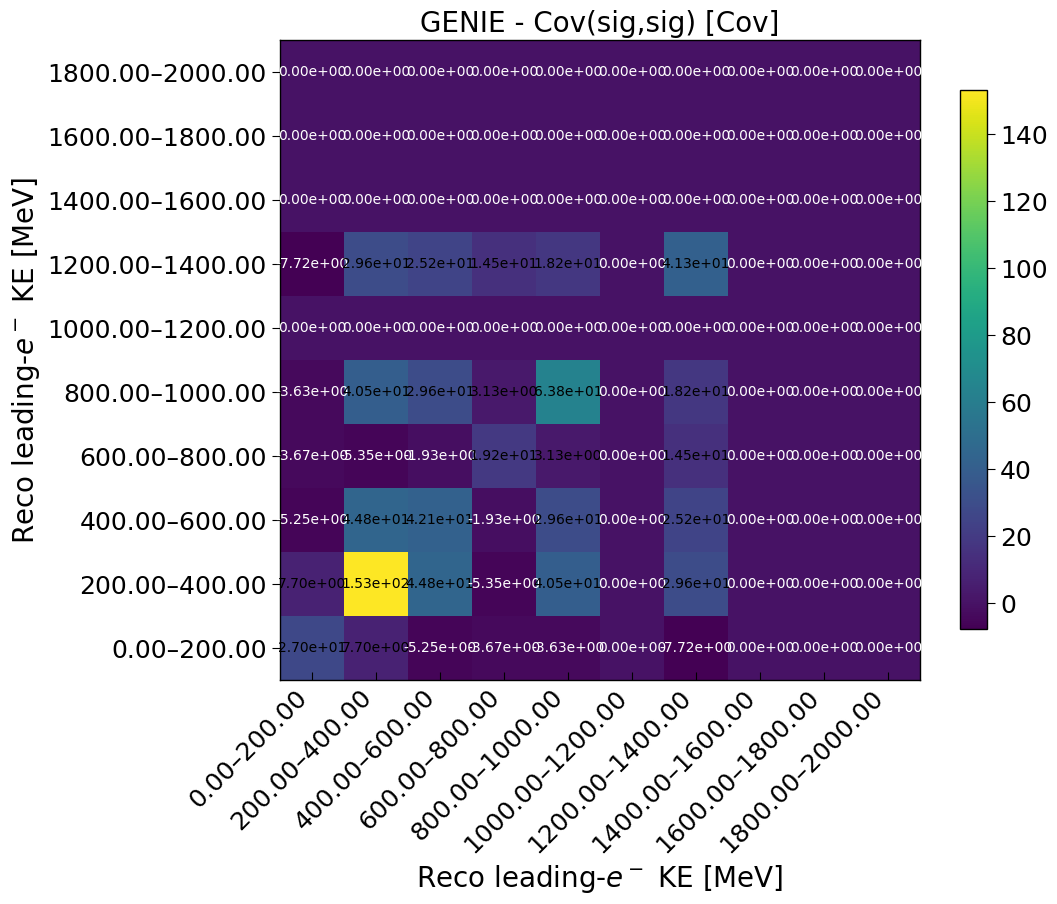

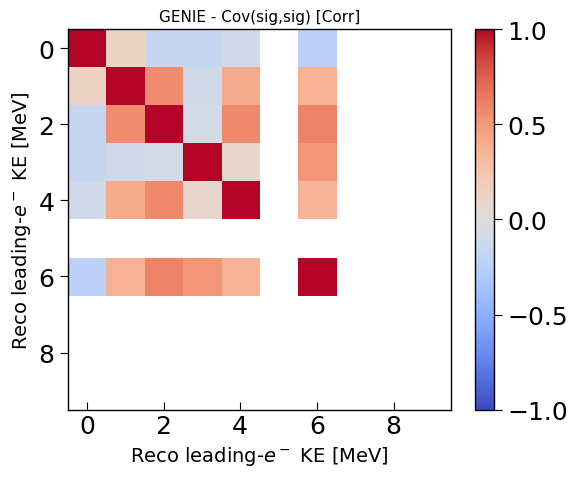

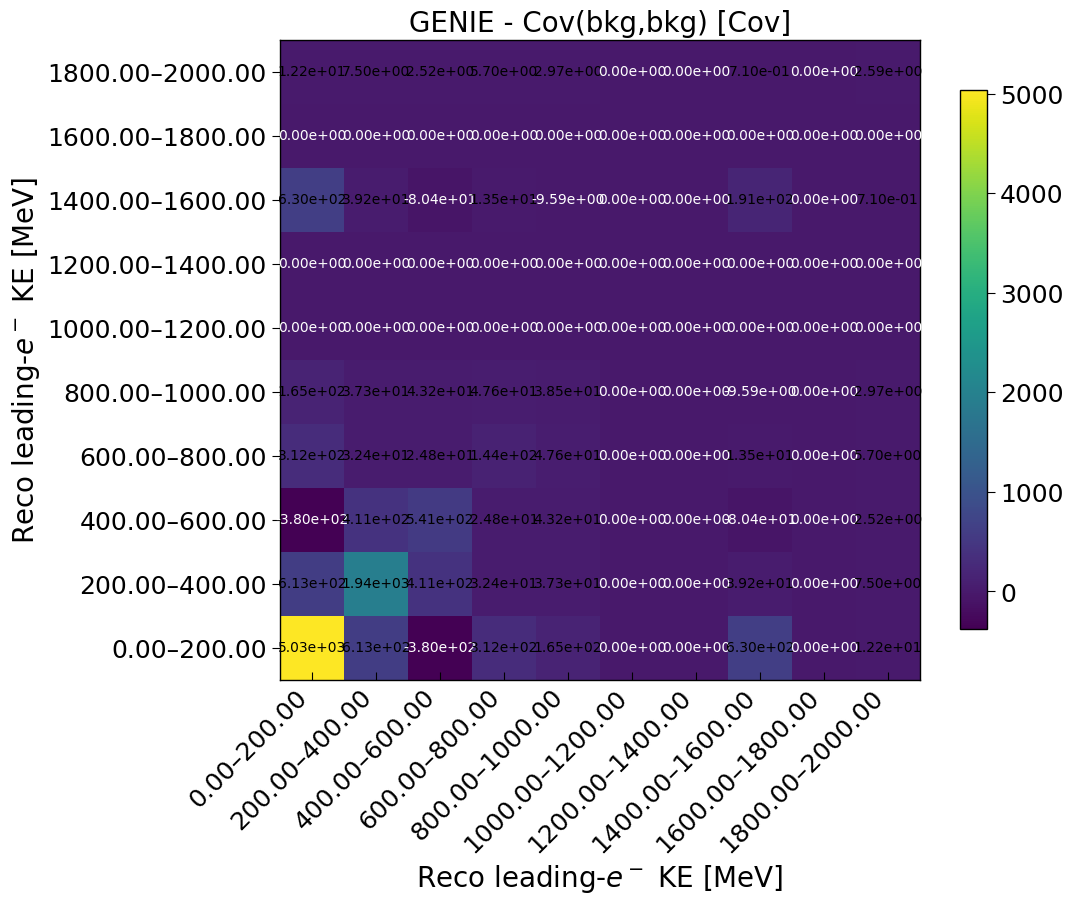

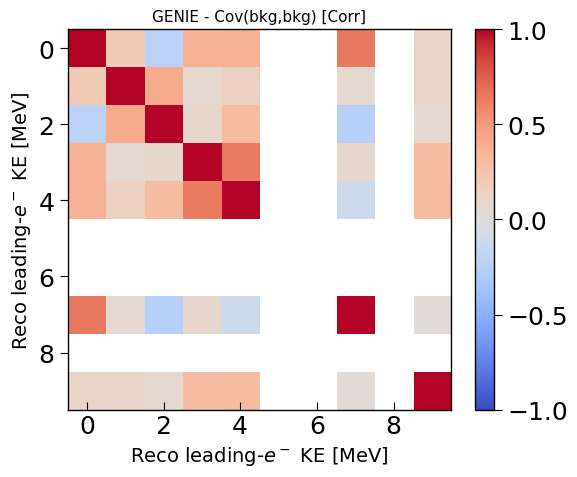

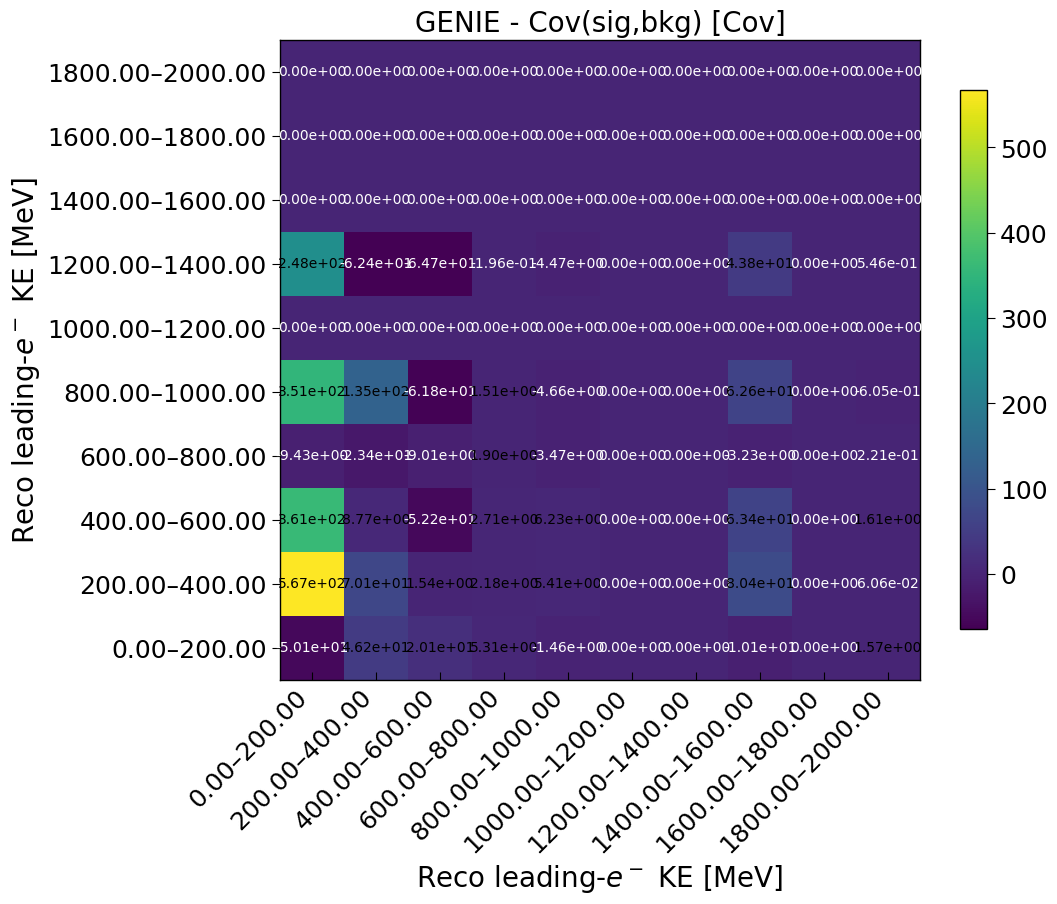

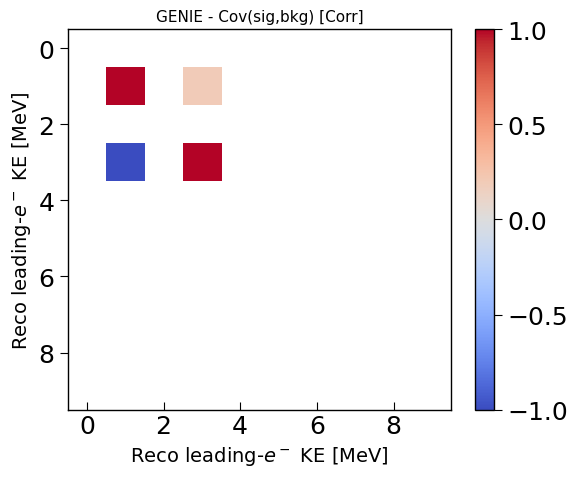

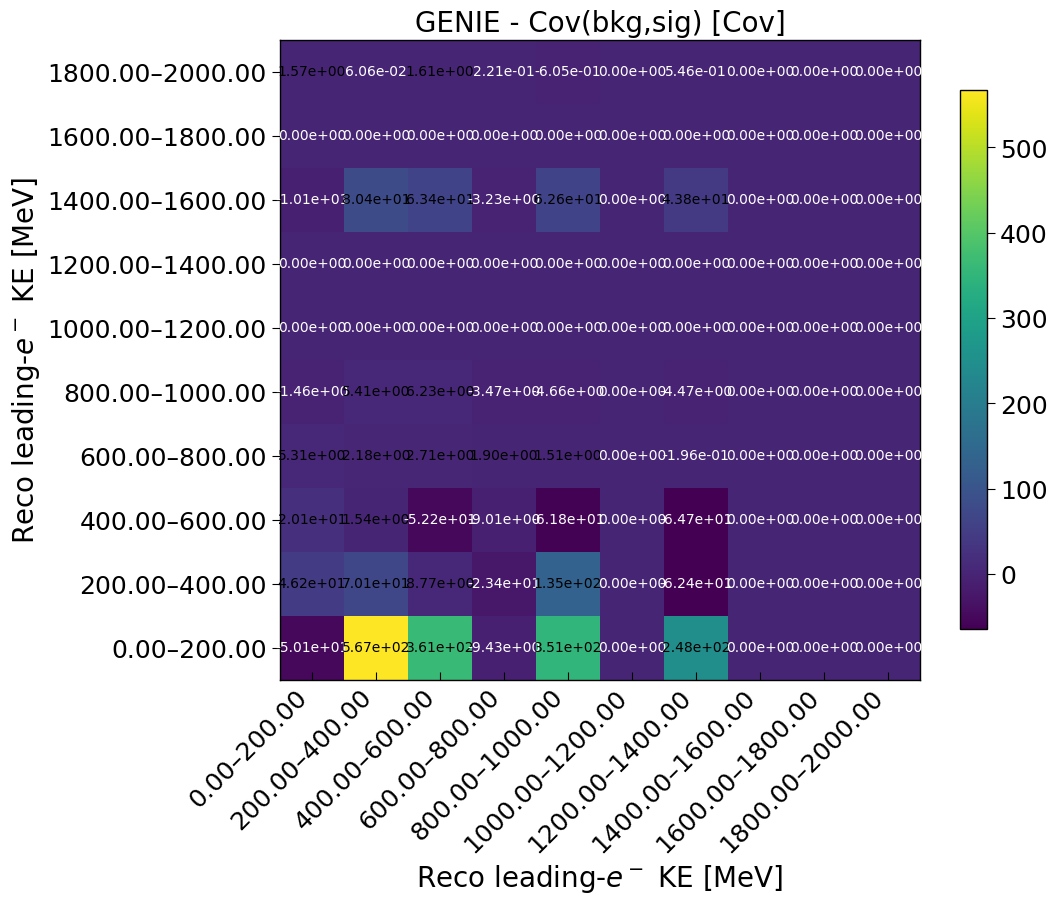

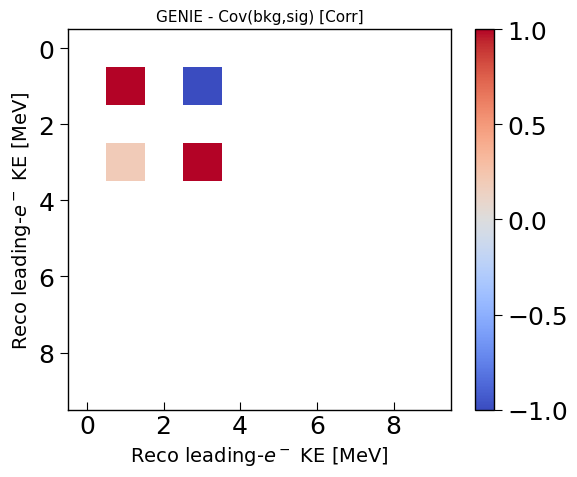

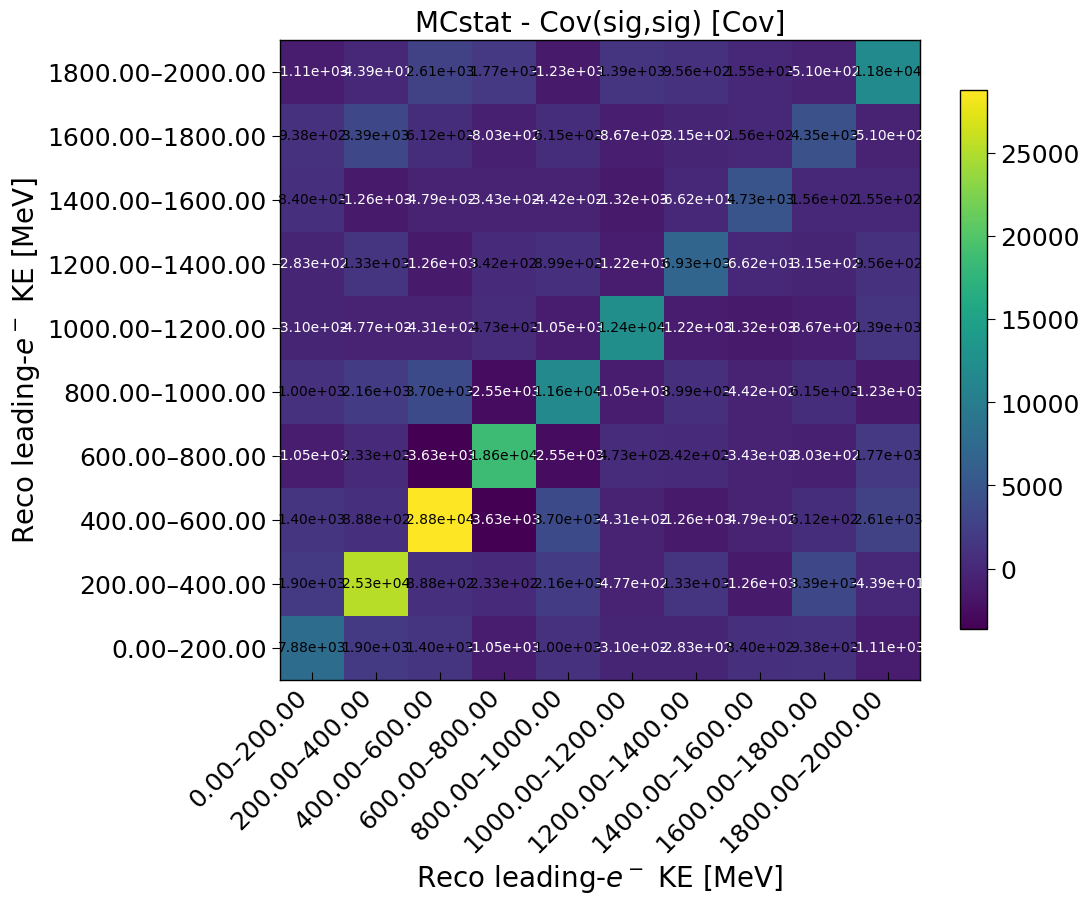

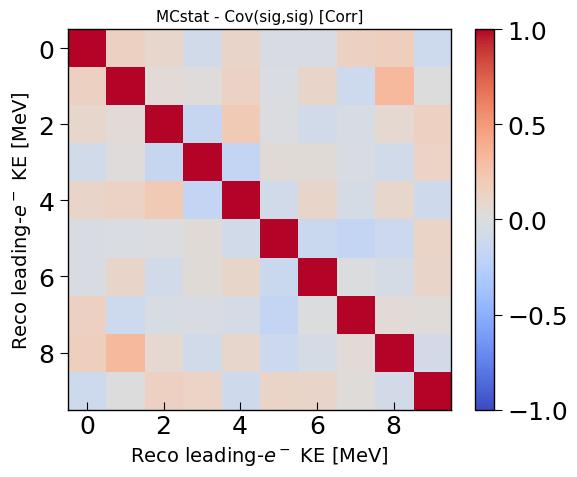

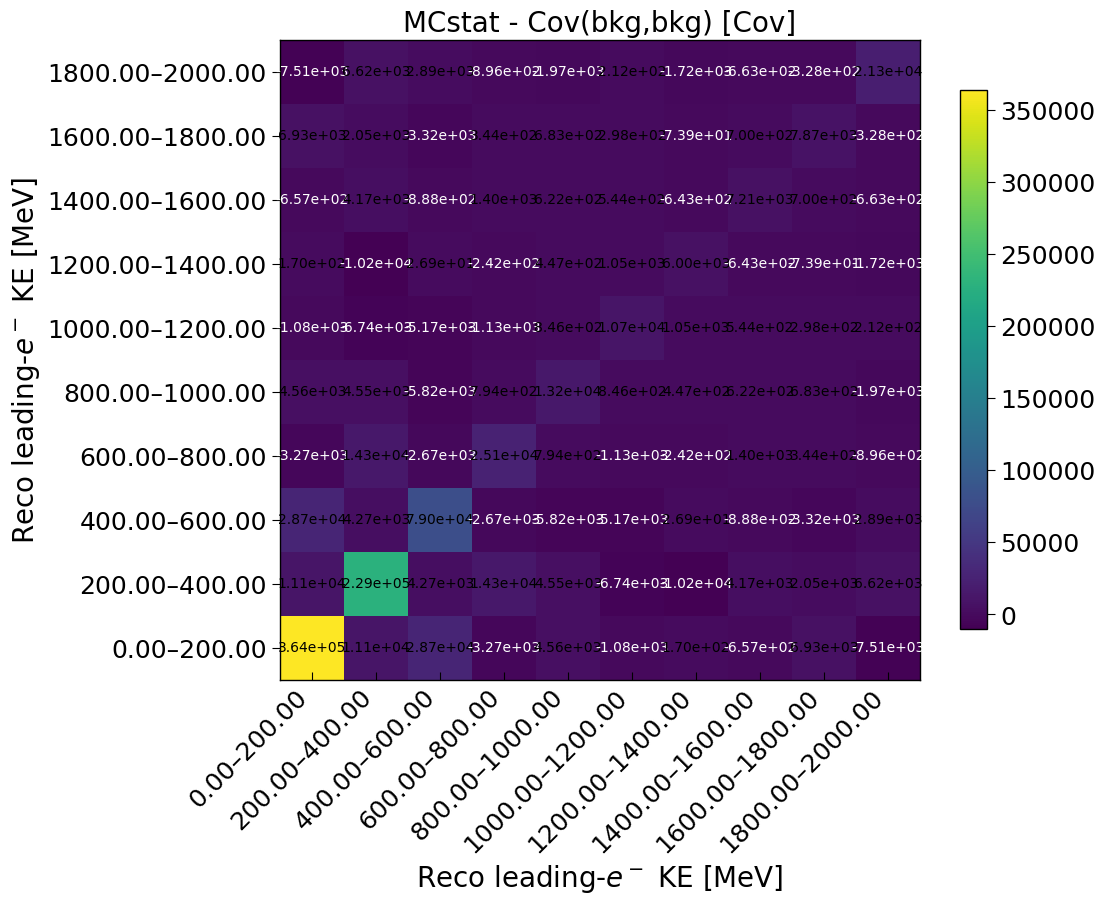

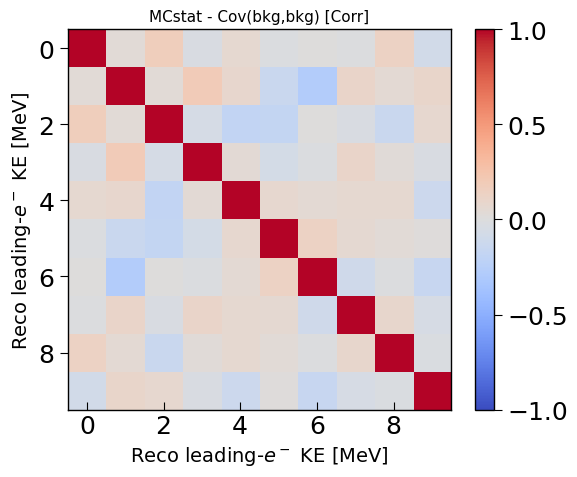

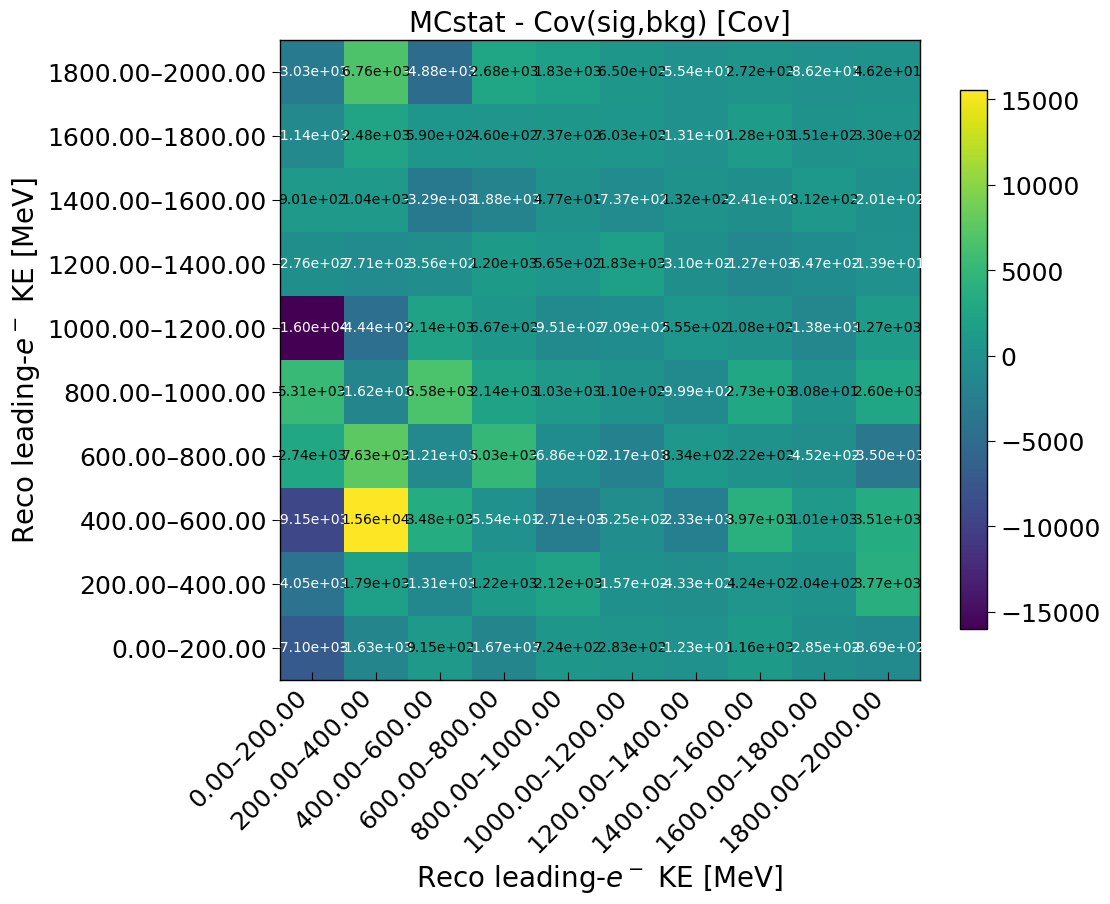

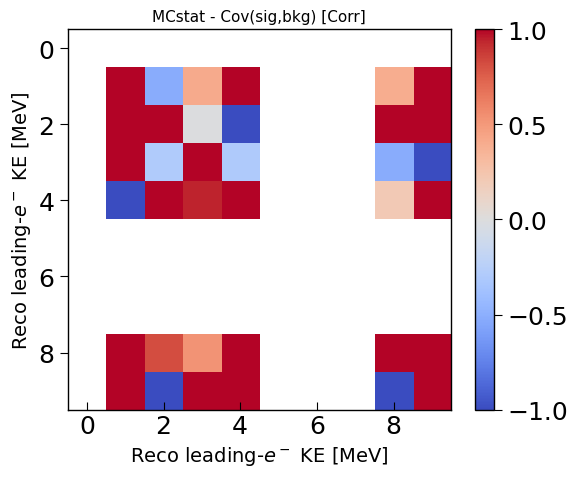

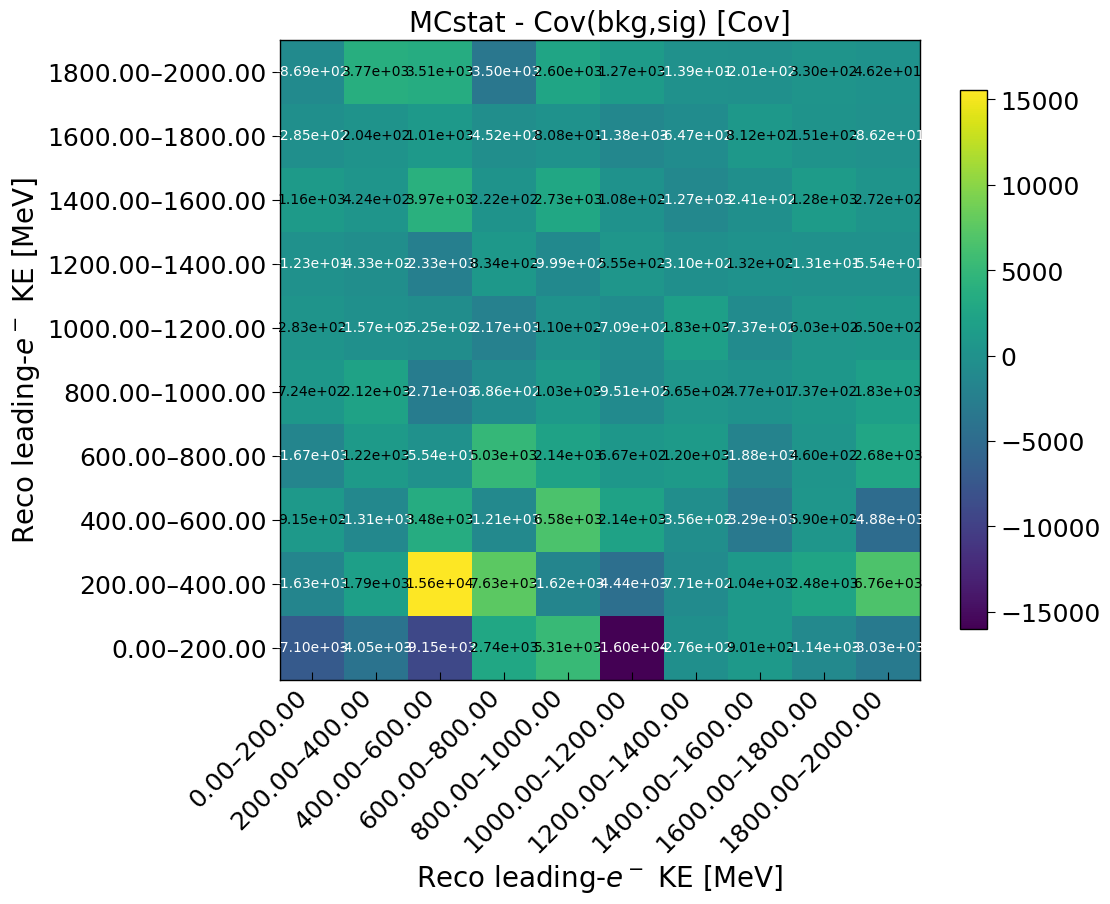

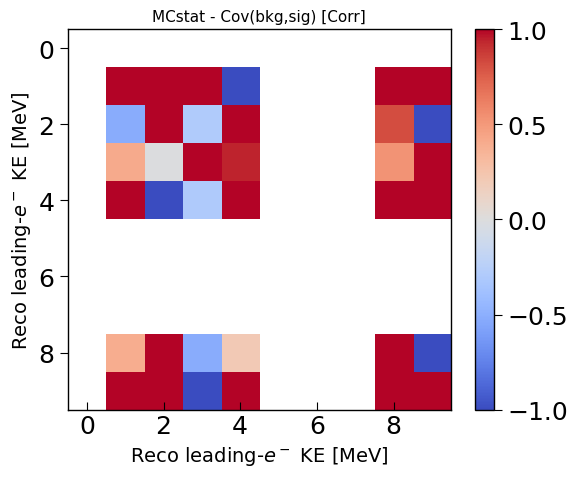

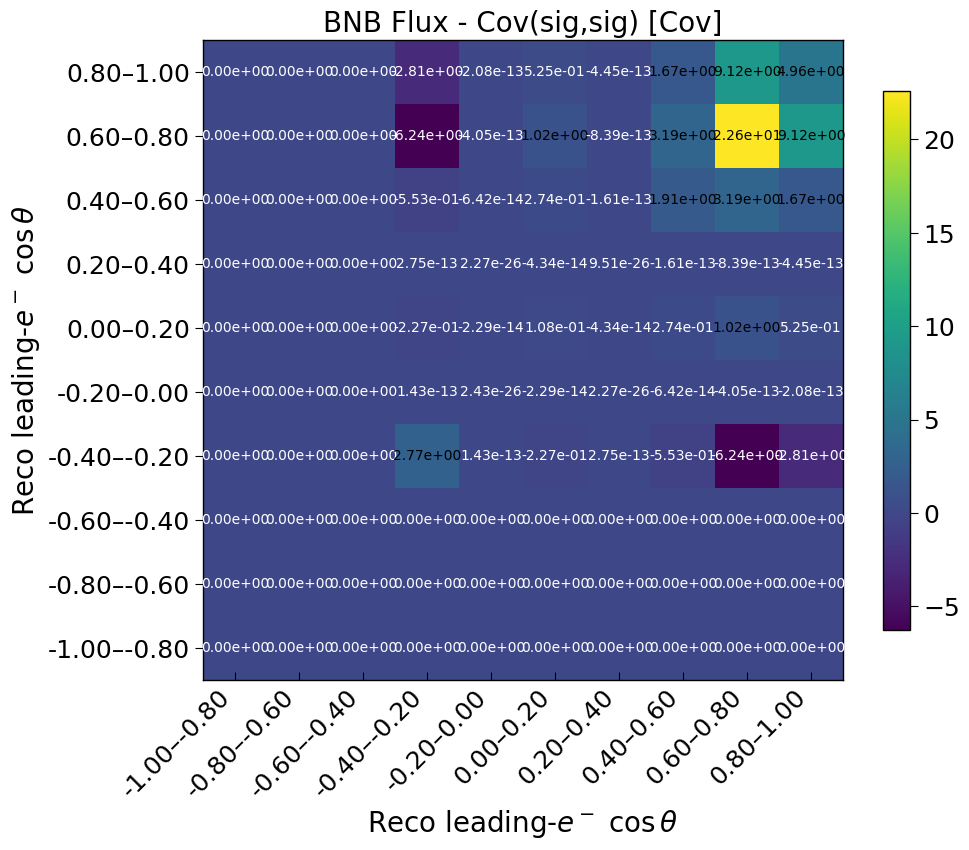

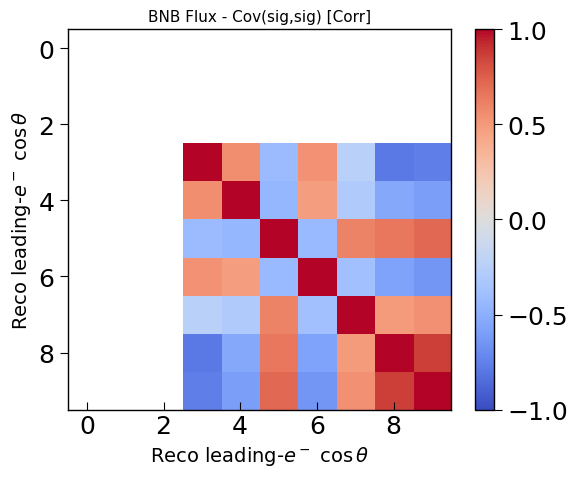

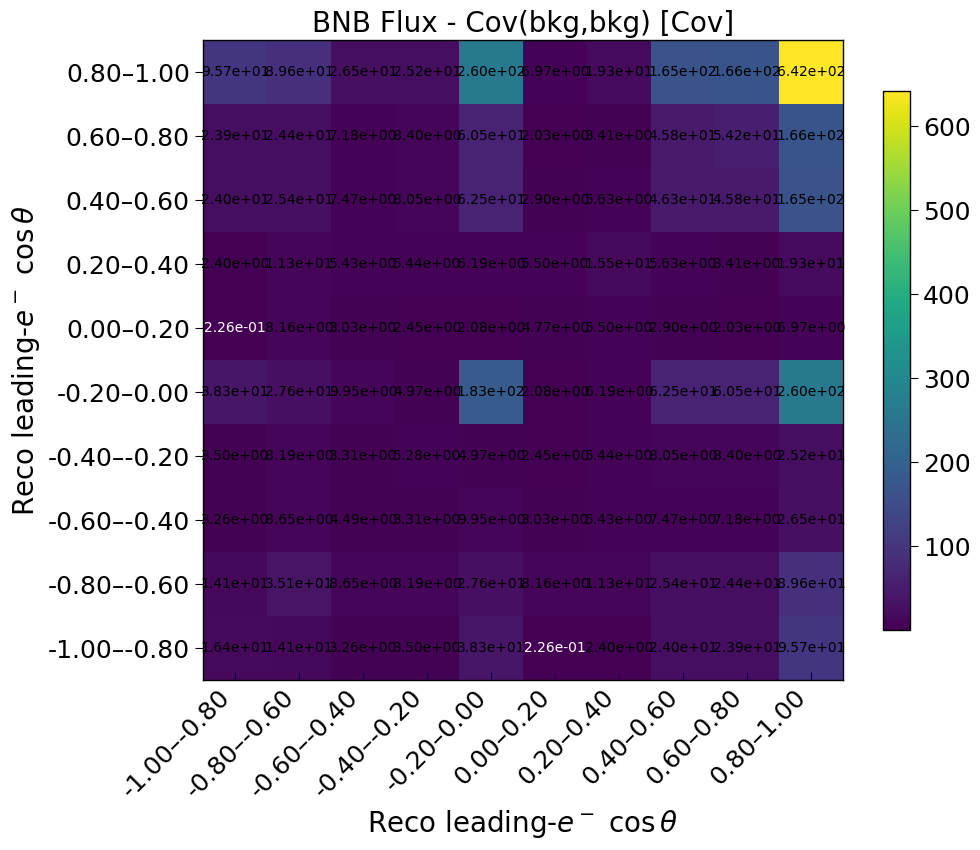

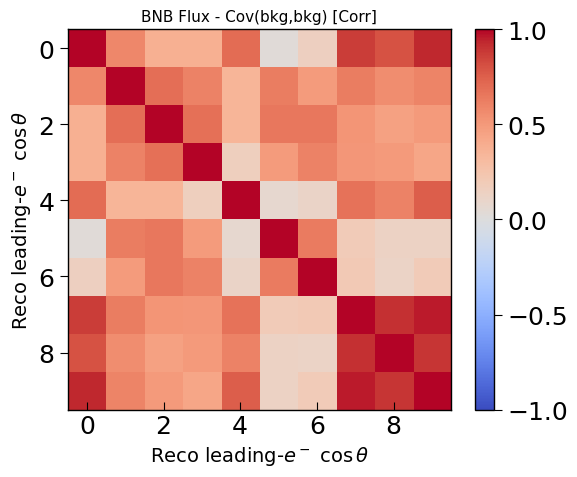

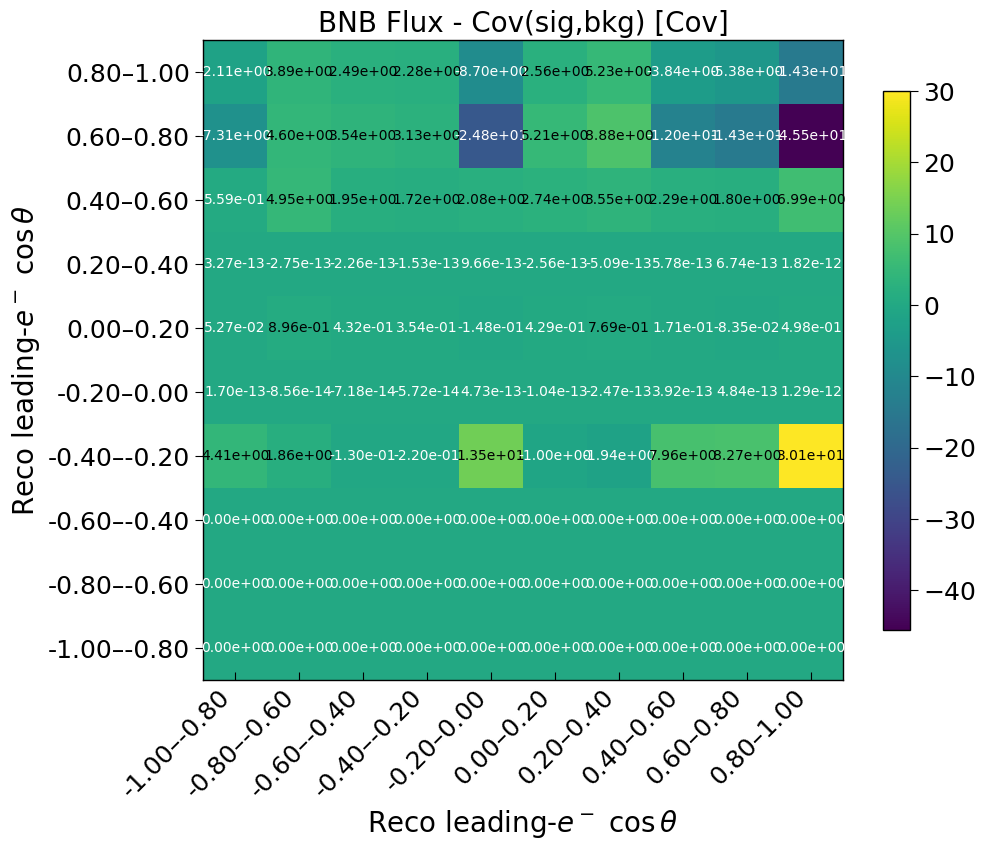

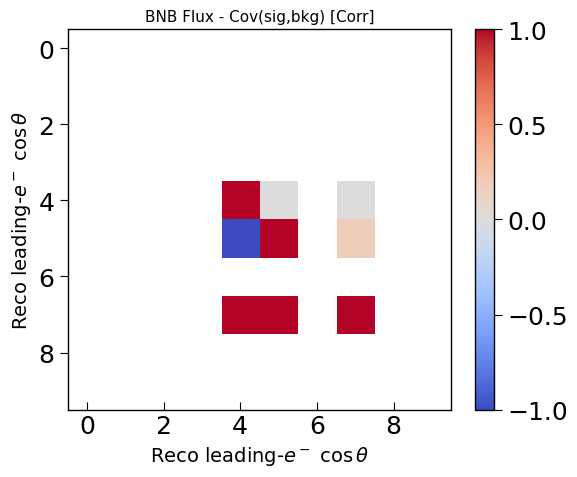

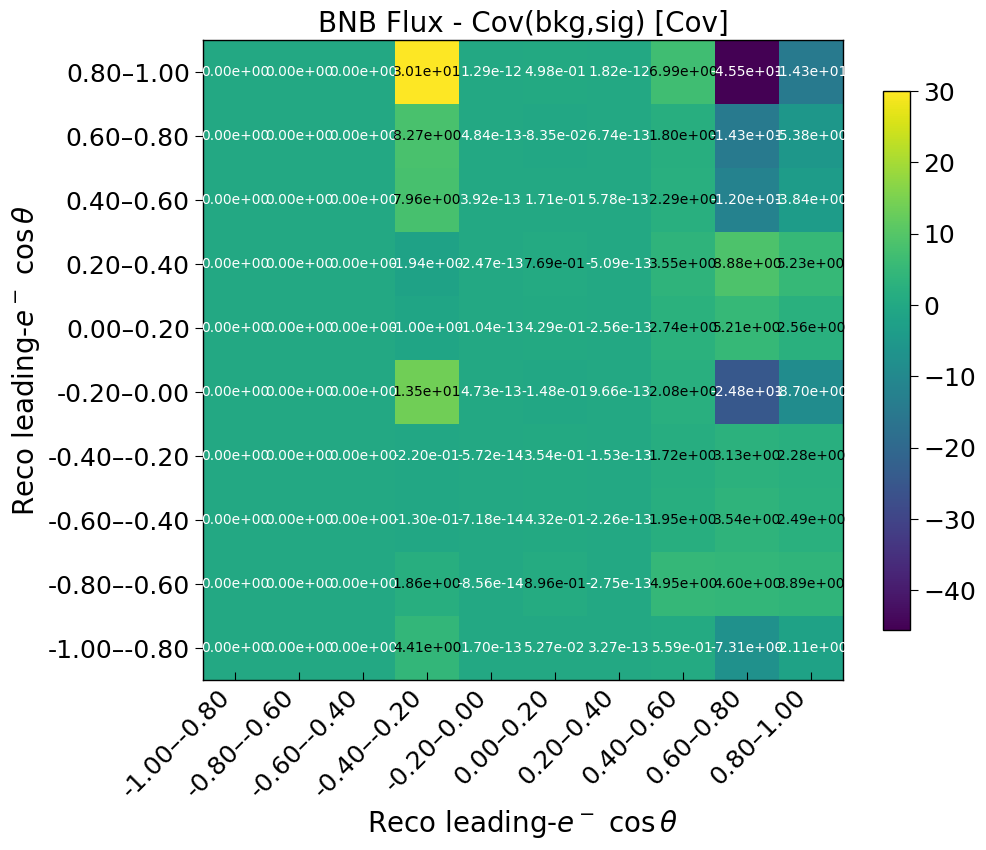

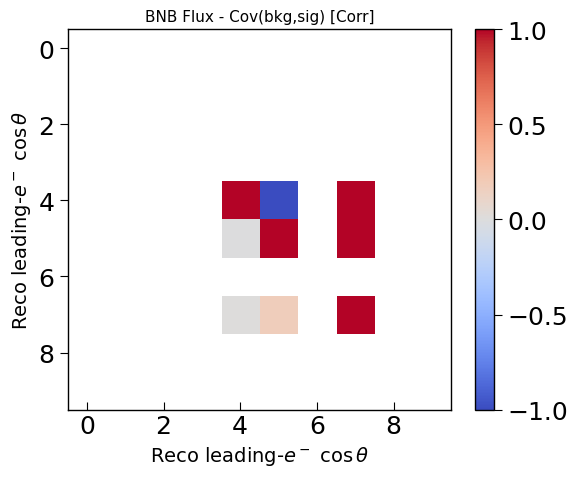

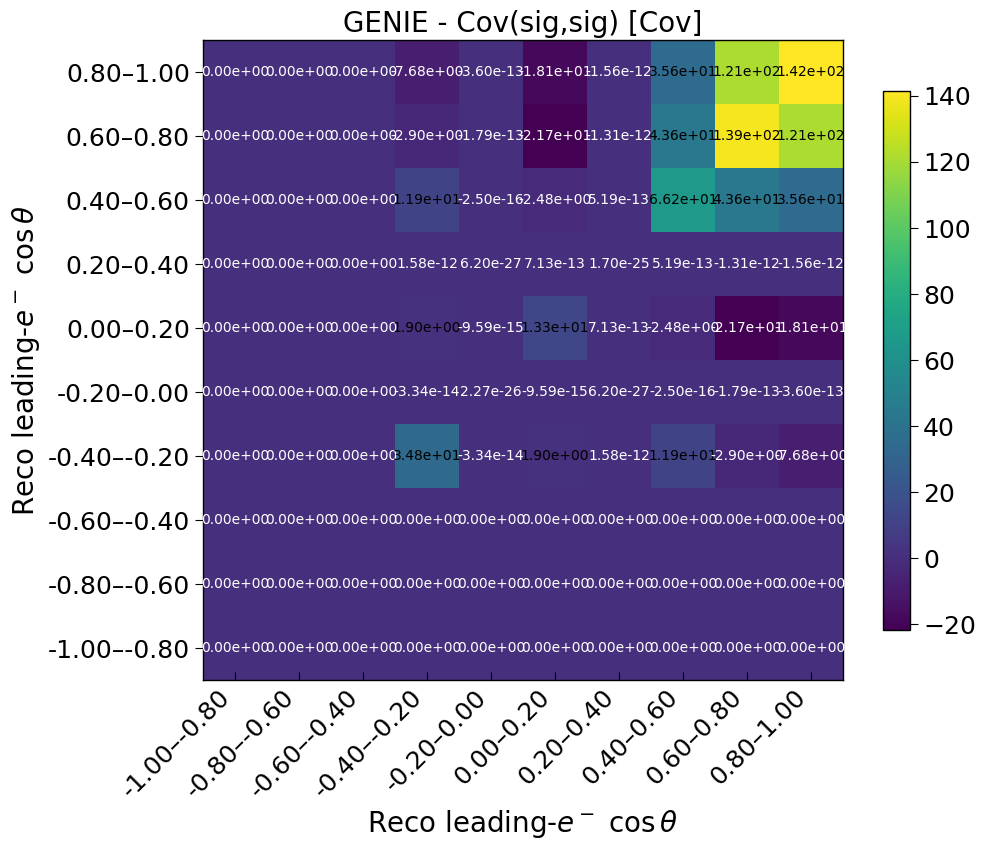

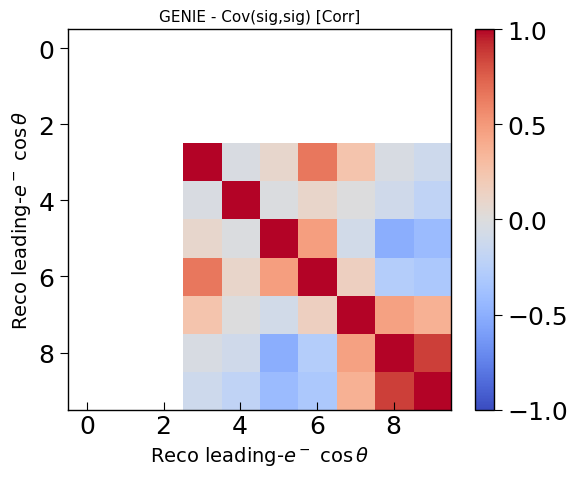

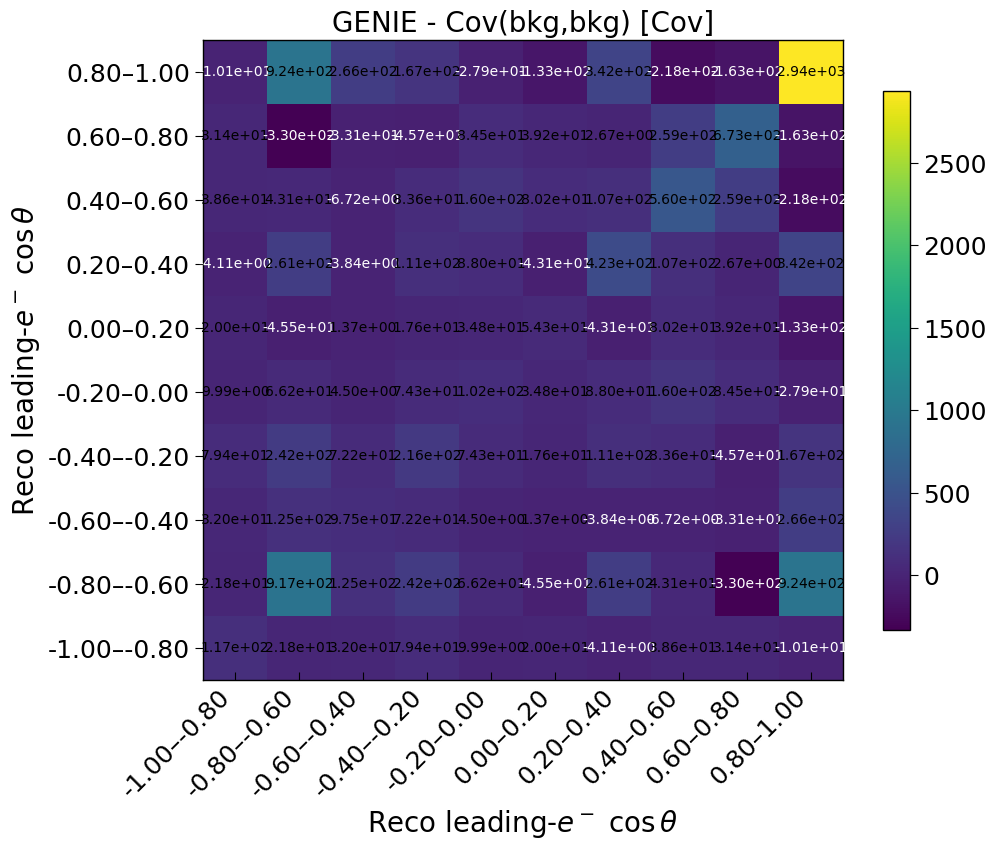

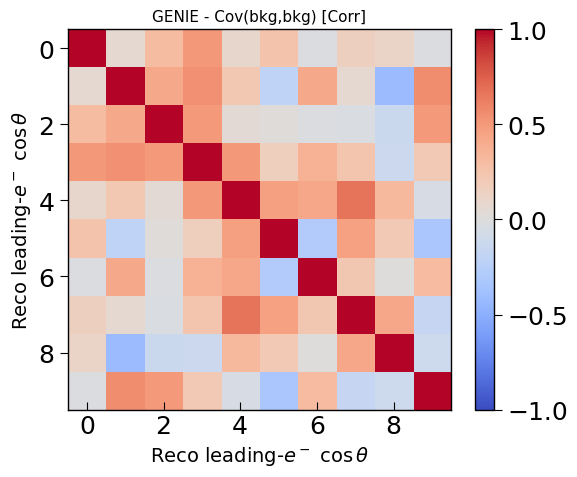

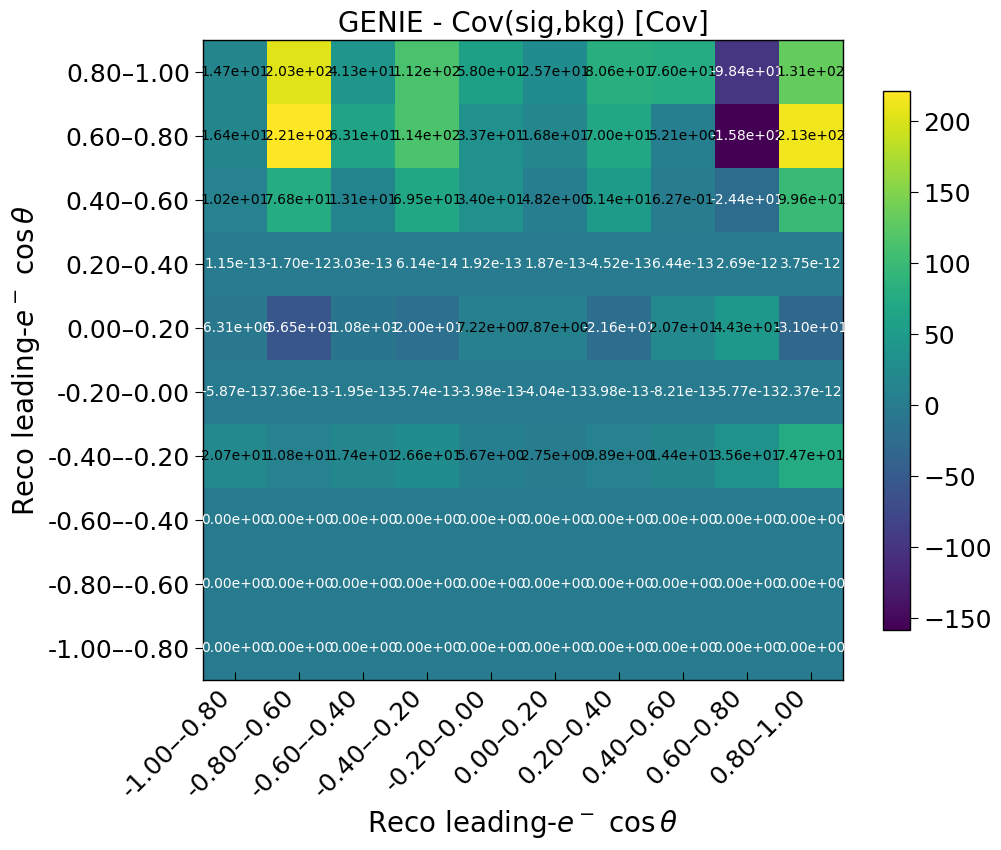

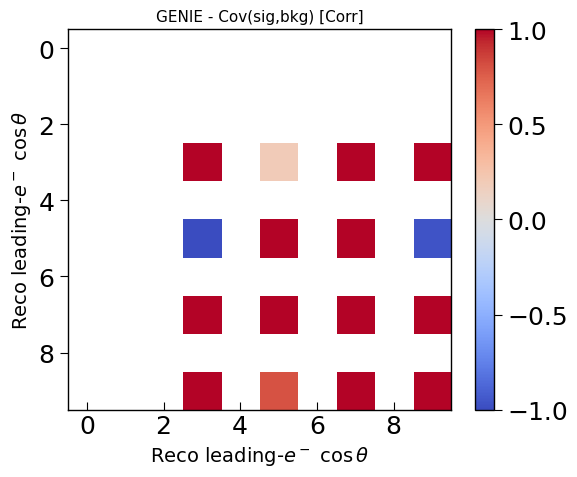

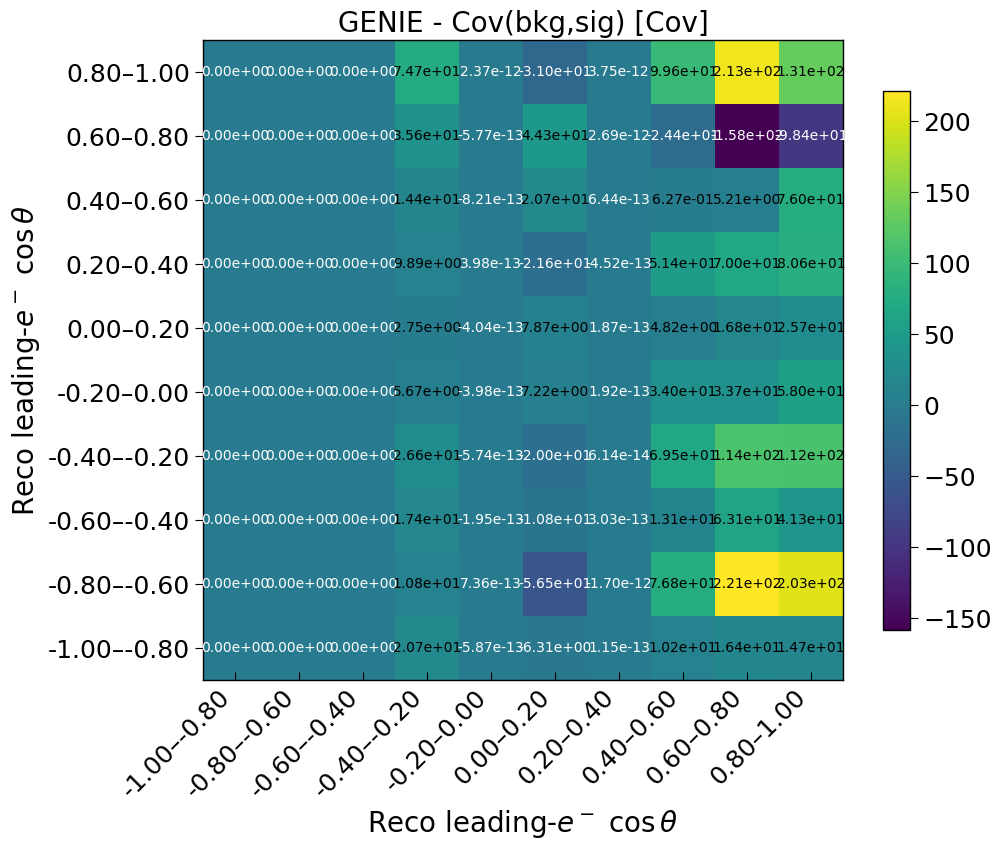

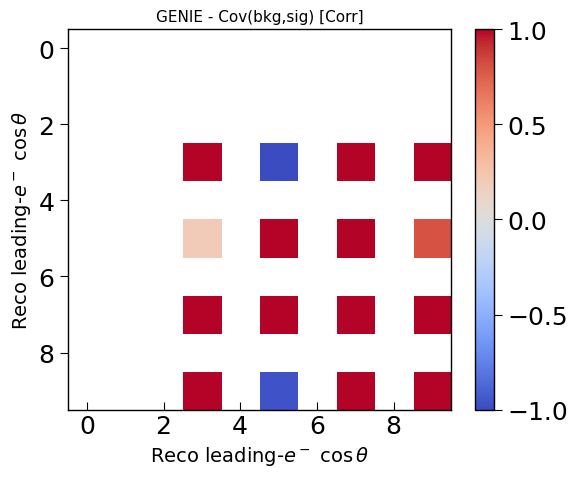

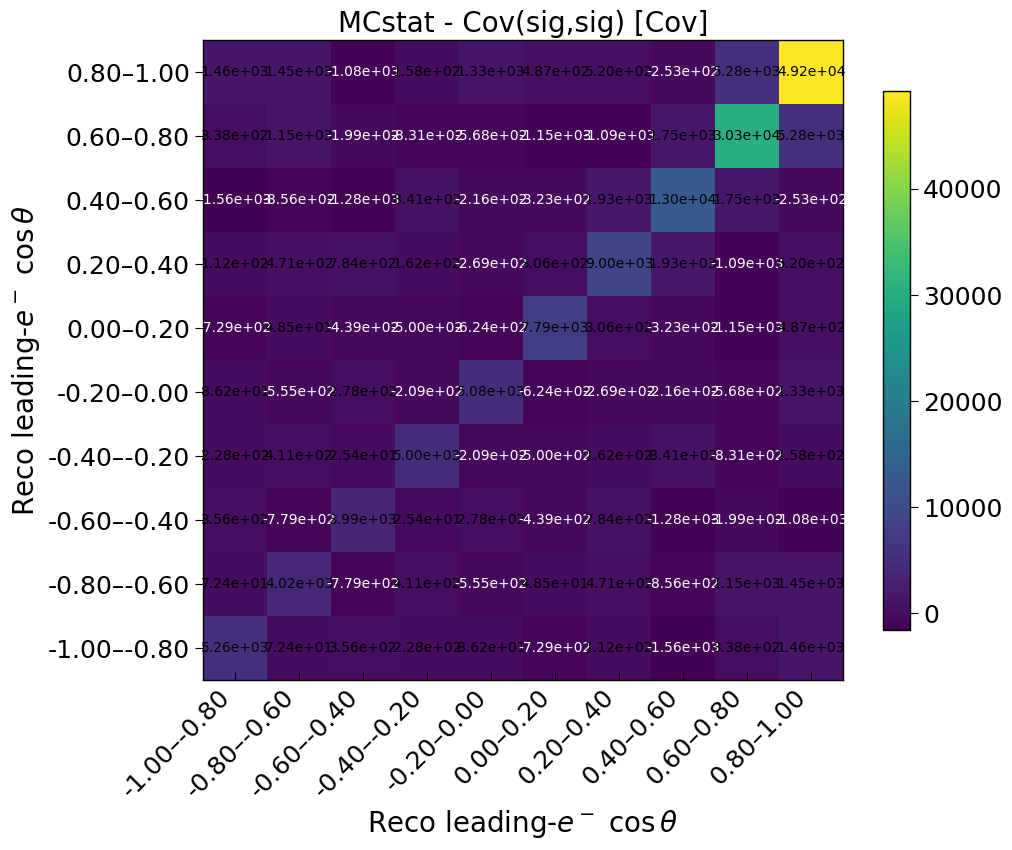

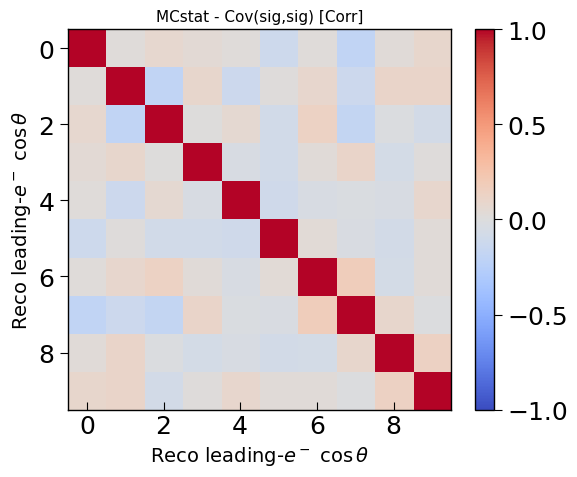

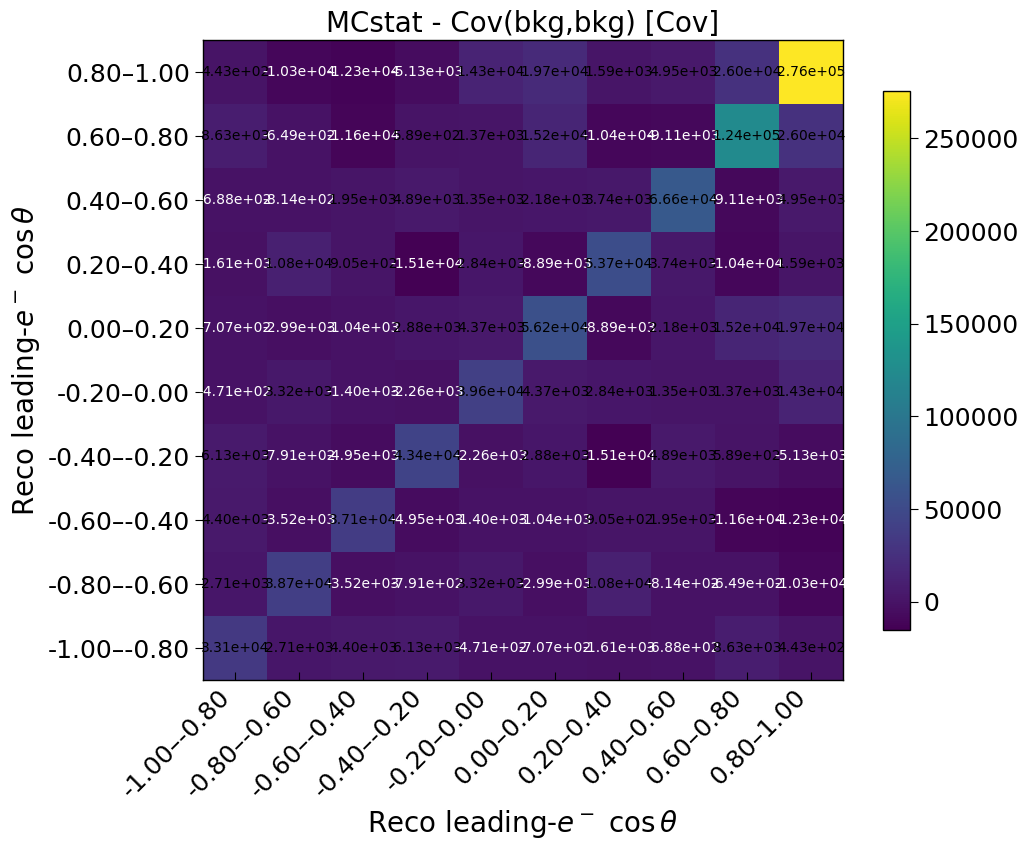

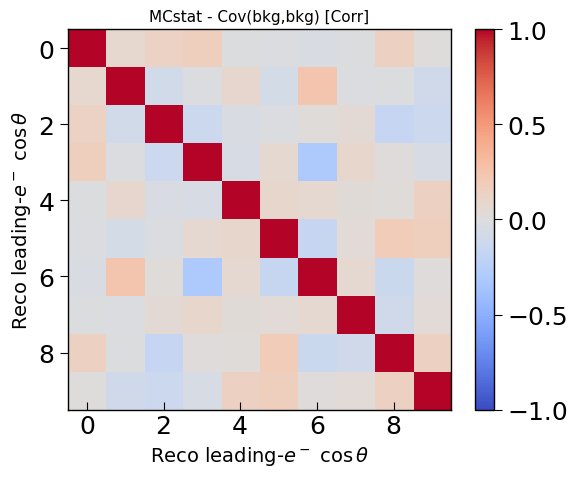

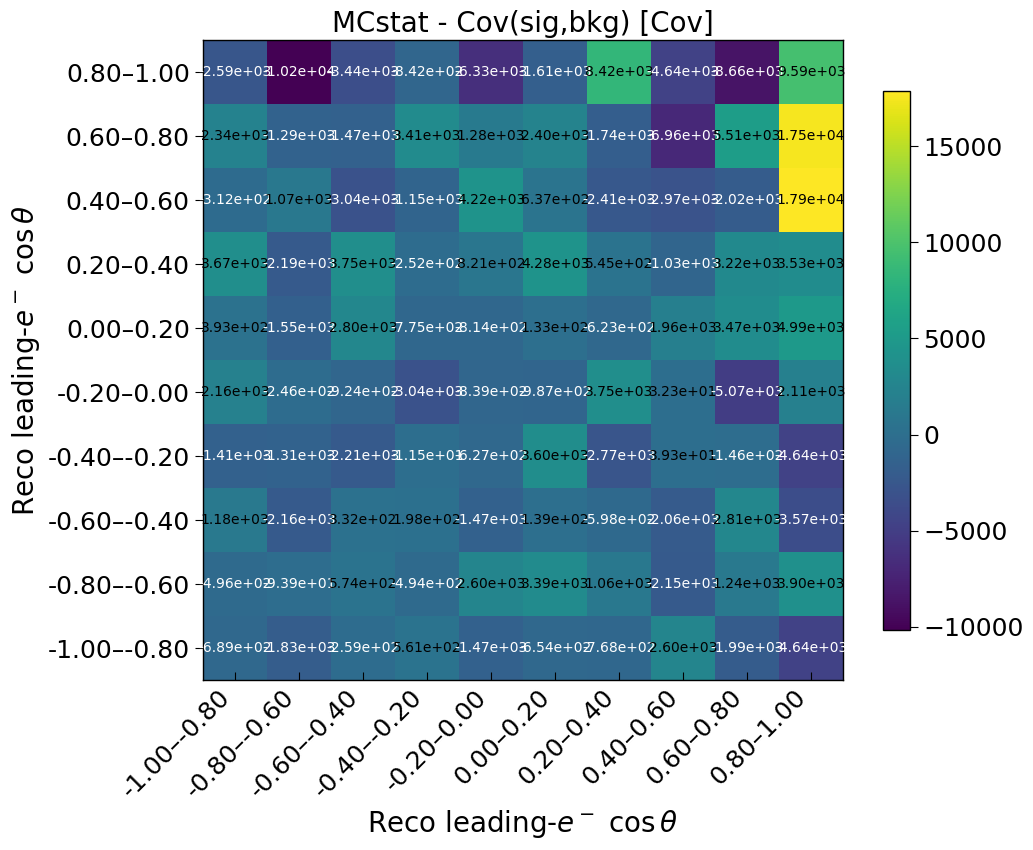

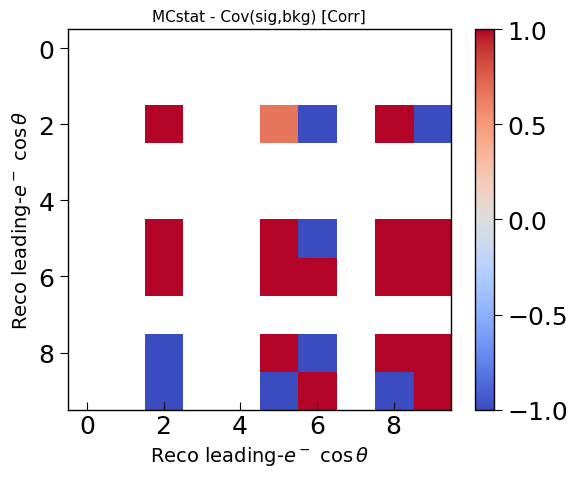

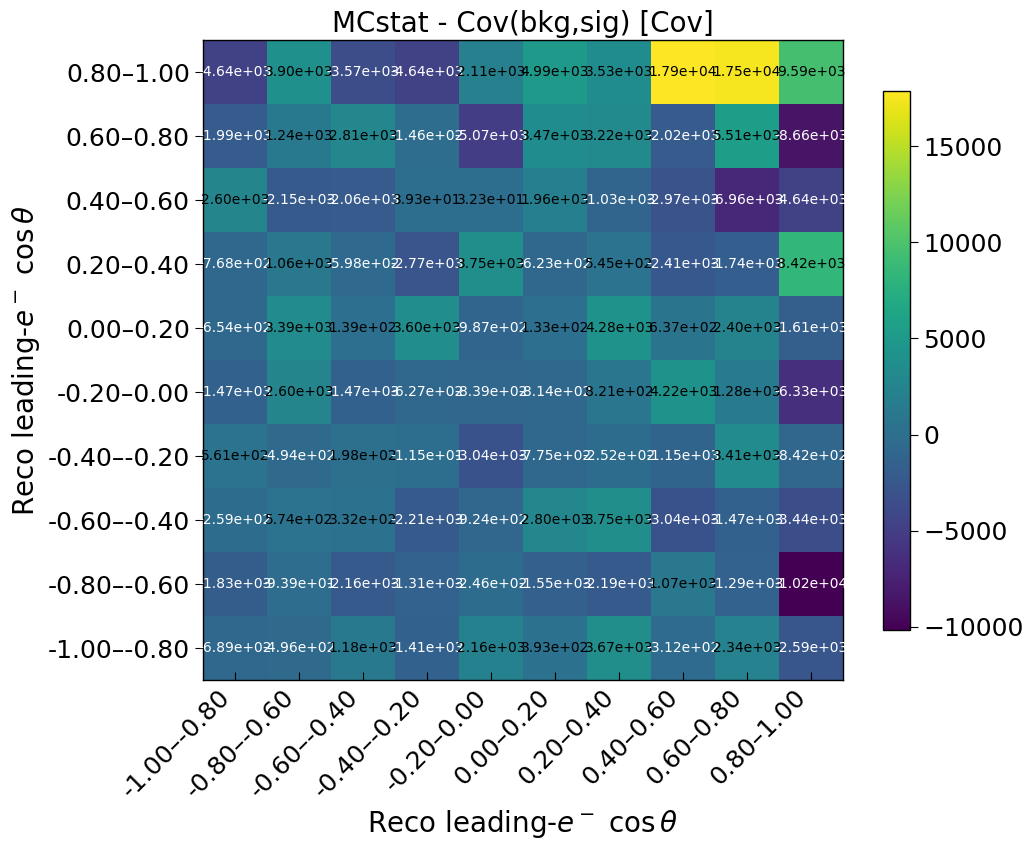

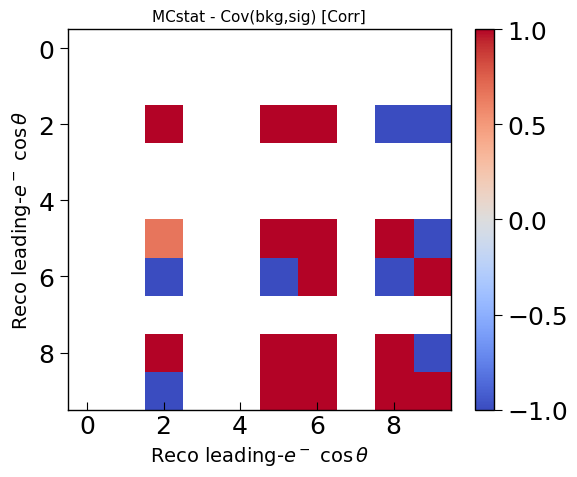

Covariance heatmaps -> plots_syst/cov/


In [25]:
for vcfg in VAR_CFGS:
    for src, covs in cov_results[vcfg.name].items():
        for bk, bl in BLOCK_LABELS.items():
            bv      = covs[bk]
            cov_mat = _mat(bv)
            corr_mat = bv.get('corr', None) if isinstance(bv, dict) else None

            # Covariance
            try:
                plot_heatmap(cov_mat, vcfg, title=f'{SRC_LABEL[src]} - {bl} [Cov]')
                savefig(plt.gcf(), f'{vcfg.name}_{src}_{bk}_cov', 'cov')
            except Exception as e:
                print(f'  [WARN] cov {vcfg.name}/{src}/{bk}: {e}')

            # Correlation — custom plot since plot_heatmap doesn't accept vmin/vmax
            if corr_mat is not None:
                try:
                    fig, ax = plt.subplots(figsize=(6, 5))
                    im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
                    plt.colorbar(im, ax=ax)
                    ax.set_title(f'{SRC_LABEL[src]} - {bl} [Corr]', fontsize=11)
                    ax.set_xlabel(vcfg.var_plot_name); ax.set_ylabel(vcfg.var_plot_name)
                    fig.tight_layout()
                    savefig(fig, f'{vcfg.name}_{src}_{bk}_corr', 'cov')
                except Exception as e:
                    print(f'  [WARN] corr {vcfg.name}/{src}/{bk}: {e}')

print('Covariance heatmaps -> plots_syst/cov/')

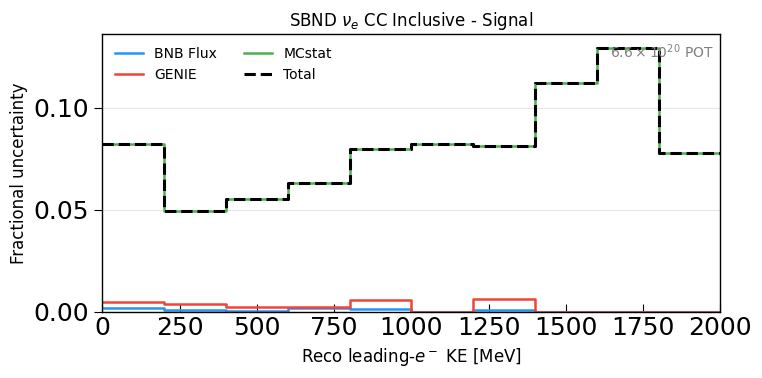

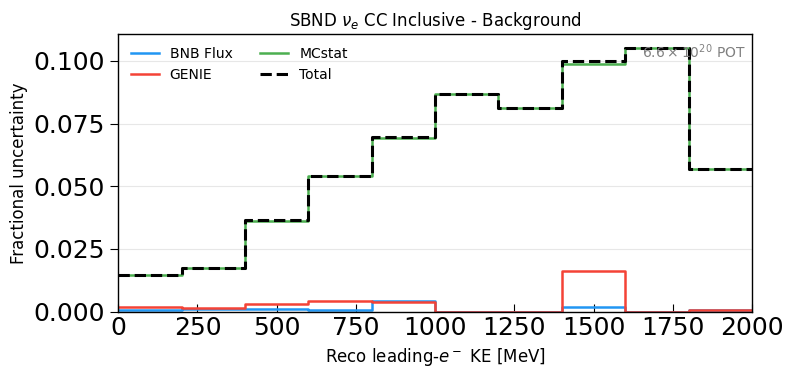

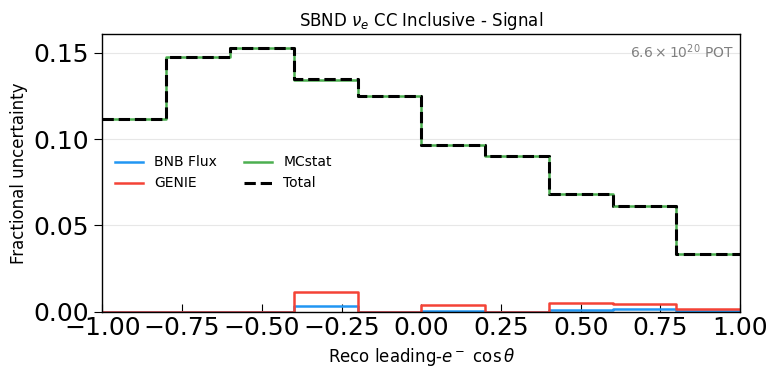

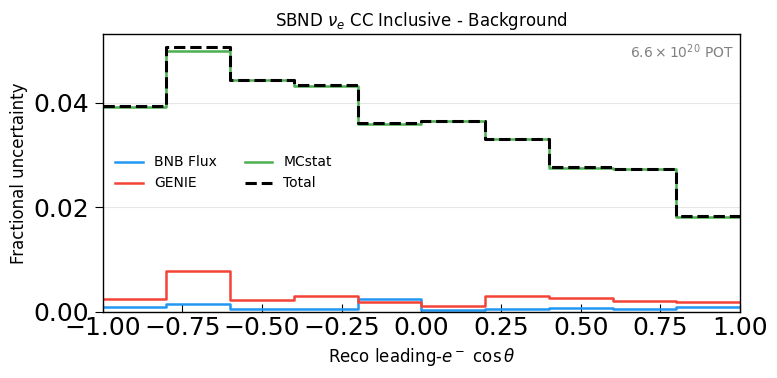

Fracunc plots -> plots_syst/fracunc/


In [26]:

COLORS = {'flux': '#2196F3', 'genie': '#F44336', 'mcstat': '#4CAF50'}

def plot_fracunc(vcfg, cv_arr, cov_results_var, block_key, categ):
    fig, ax = plt.subplots(figsize=(8, 4))
    total_var = np.zeros(len(vcfg.bin_centers))
    for src, covs in cov_results_var.items():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            diag = np.diag(_mat(covs[block_key])).clip(0)
            frac = np.where(cv_arr > 0, np.sqrt(diag) / cv_arr, 0.0)
        xe = np.append(vcfg.bins[:-1], vcfg.bins[-1])
        ye = np.append(frac, frac[-1])
        ax.step(xe, ye, where='post', label=SRC_LABEL[src],
                color=COLORS.get(src, 'gray'), lw=1.8)
        total_var += diag
    tot = np.where(cv_arr > 0, np.sqrt(total_var) / cv_arr, 0.0)
    ax.step(np.append(vcfg.bins[:-1], vcfg.bins[-1]),
            np.append(tot, tot[-1]),
            where='post', label='Total', color='black', lw=2.2, ls='--')
    ax.set_xlabel(vcfg.var_plot_name, fontsize=12)
    ax.set_ylabel('Fractional uncertainty', fontsize=12)
    ax.set_title(f'{TITLE} - {categ}', fontsize=12)
    ax.legend(fontsize=10, ncol=2)
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1]); ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.99, 0.97, vcfg.pot_label, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')
    fig.tight_layout(); return fig

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]; covs_var = cov_results[vcfg.name]
    for bk, categ, cv_arr in [
        ('cov_ms_ms', 'Signal',     cv['sig_cv']),
        ('cov_bs_bs', 'Background', cv['bkg_cv']),
    ]:
        fig = plot_fracunc(vcfg, cv_arr, covs_var, bk, categ)
        savefig(fig, f'{vcfg.name}_fracunc_{categ.lower()}', 'fracunc')
print('Fracunc plots -> plots_syst/fracunc/')


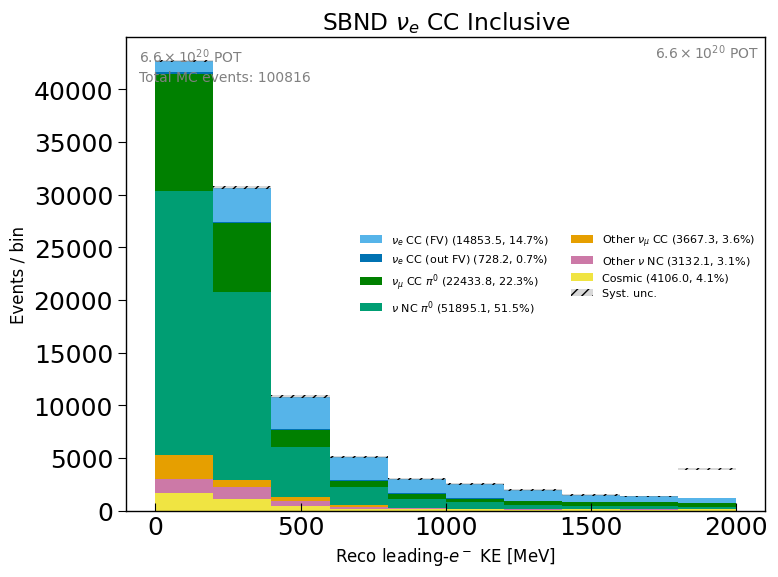

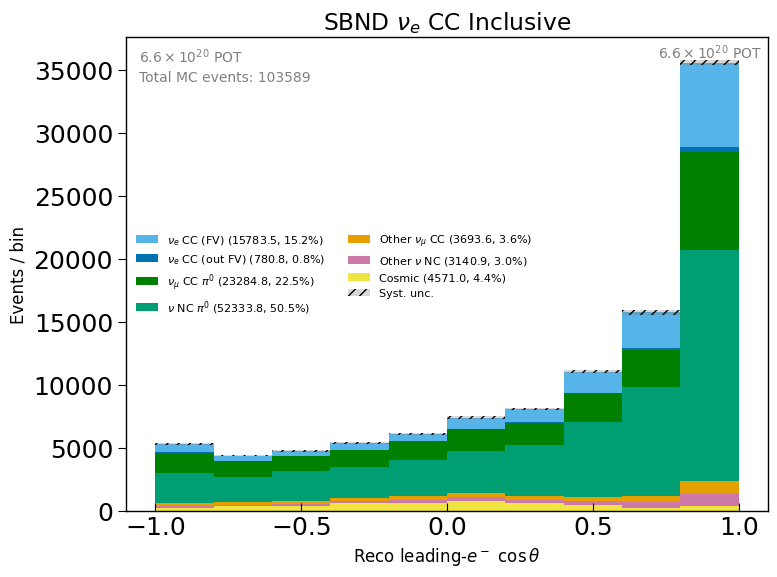

Stacked+syst plots -> plots_syst/


In [27]:

try:
    import nue_helpers as nh; HAS_NH = True
except ImportError:
    HAS_NH = False; print('nue_helpers not found - using fallback')

DISPLAY_CATS   = [0, 1, 2, 3, 4, 5, 6]
FALLBACK_CLRS  = ['#1f77b4','#aec7e8','#ff7f0e','#ffbb78',
                  '#2ca02c','#98df8a','#d62728']
FALLBACK_LBLS  = [r'$\nu_e$ CC FV (sig)', r'$\nu_e$ CC out FV',
                  r'$\nu_\mu$ CC+$\pi^0$', r'NC $\pi^0$',
                  r'Other $\nu_\mu$ CC', 'Other NC', 'Cosmic']

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]; covs_var = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0)
                    for s in covs_var)
    unc   = np.sqrt(total_var)
    total = cv['sig_cv'] + cv['bkg_cv']
    bw    = np.diff(vcfg.bins)

    fig, ax = plt.subplots(figsize=(8, 6))
    if HAS_NH:
        def _cat(col, cat):
            m = sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == cat)
            return sel_topo.loc[m, col].dropna().values
        nh.plot_stacked_hist(
            series_list=[_cat(vcfg.name, c) for c in DISPLAY_CATS],
            labels=[nh.CAT_LABELS[c] for c in DISPLAY_CATS],
            colors=[nh.CAT_COLORS[c] for c in DISPLAY_CATS],
            bins=vcfg.bins, weights=pot_scale,
            xlabel=vcfg.var_plot_name, title=TITLE, pot_label=POT_LABEL,
            ax=ax, invert_stack_order=True)
    else:
        bot = np.zeros(len(vcfg.bin_centers))
        for i, cat in enumerate(DISPLAY_CATS):
            m = sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == cat)
            v, _ = np.histogram(
                sel_topo.loc[m, vcfg.name].clip(vcfg.bins[0], vcfg.bins[-1]-1e-8),
                bins=vcfg.bins, weights=np.full(m.sum(), pot_scale))
            ax.bar(vcfg.bin_centers, v, width=bw, bottom=bot,
                   label=FALLBACK_LBLS[i], color=FALLBACK_CLRS[i], alpha=0.85)
            bot += v
        ax.set_xlabel(vcfg.var_plot_name, fontsize=12)
        ax.set_ylabel(f'Events / {TARGET_POT:.1e} POT', fontsize=12)
        ax.set_title(TITLE, fontsize=12)

    ax.bar(vcfg.bins[:-1], 2*unc, bottom=total-unc, width=bw, align='edge',
           alpha=0.3, color='gray', hatch='///', label='Syst. unc.', linewidth=0)
    ax.legend(fontsize=8, ncol=2)
    ax.text(0.99, 0.99, POT_LABEL, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')
    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band')
print('Stacked+syst plots -> plots_syst/')


In [28]:

print(f'\n{"="*68}')
print(f'{"Variable":<16} {"Source":<10} {"Category":<14} {"Mean frac. unc.":>16}')
print(f'{"="*68}')
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        for bk, categ, cv_arr in [
            ('cov_ms_ms', 'Signal',     cv['sig_cv']),
            ('cov_bs_bs', 'Background', cv['bkg_cv']),
        ]:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                frac = np.where(cv_arr > 0,
                    np.sqrt(np.diag(_mat(covs[bk])).clip(0)) / cv_arr, np.nan)
            fu = float(np.nanmean(frac))
            print(f'  {vcfg.name:<14} {src:<10} {categ:<14} {fu*100:>14.2f}%')
print(f'{"="*68}')
print(f'\nNPZ files -> {SYST_DIR}/')
for vcfg in VAR_CFGS:
    vd = f'{SYST_DIR}/{vcfg.name}'
    if os.path.isdir(vd):
        print(f'  {vcfg.name}: {os.listdir(vd)}')
print(f'Plots     -> {PLOT_DIR}/')
for sub in ['univ', 'cov', 'fracunc']:
    sd = f'{PLOT_DIR}/{sub}'
    if os.path.isdir(sd):
        print(f'  {sub}/: {len(os.listdir(sd))} files')



Variable         Source     Category        Mean frac. unc.
  reco_ke        flux       Signal                   0.07%
  reco_ke        flux       Background               0.10%
  reco_ke        genie      Signal                   0.25%
  reco_ke        genie      Background               0.31%
  reco_ke        mcstat     Signal                   8.12%
  reco_ke        mcstat     Background               6.20%
  reco_costheta  flux       Signal                   0.06%
  reco_costheta  flux       Background               0.09%
  reco_costheta  genie      Signal                   0.26%
  reco_costheta  genie      Background               0.28%
  reco_costheta  mcstat     Signal                  10.21%
  reco_costheta  mcstat     Background               3.56%

NPZ files -> ./saved_syst/
  reco_ke: ['total_cov_matrices.npz', 'flux_cov_matrices.npz', 'genie_cov_matrices.npz', 'mcstat_cov_matrices.npz']
  reco_costheta: ['total_cov_matrices.npz', 'flux_cov_matrices.npz', 'genie_cov_matrice

In [29]:
# Check what fraction of weights are NaN in wgt_aligned
nan_frac = wgt_aligned[bnb_cols_aligned].isna().mean().mean()
print(f'NaN fraction in BNB weights: {nan_frac:.1%}')

# Check a few weight values for matched rows
matched = wgt_aligned[bnb_cols_aligned[0]].notna()
print(f'Matched interactions: {matched.sum()} / {len(matched)}')
print(wgt_aligned.loc[matched, bnb_cols_aligned[:3]].describe())

NameError: name 'wgt_aligned' is not defined